# 01 — Data Audit

**Project:** Discovering New EuroLeague Player Roles Using Unsupervised Learning

**Research question:** Can natural EuroLeague player roles be discovered from performance
data without relying on traditional position labels such as Guard, Forward, and Center?

**Intended unit of observation (final model, later task):** player-season-team.

## Purpose of this notebook

This notebook performs a **Data Audit** of the four project data files. The goal is to
build a documented, validated, reproducible understanding of the raw and derived data
*before* any modeling work begins. It establishes:

- What each file actually contains (rows, columns, types, granularity).
- Whether the expected keys are complete and unique.
- Where missing values, duplicates, and inconsistent values exist.
- How the season-level statistics and the event-level (shot/action) data relate to
  each other, and where they diverge.
- Whether the previously produced merged dataset (`data/processed/merged_euroleague_players.csv`)
  can be reproduced from the raw files.
- A preliminary inventory of candidate columns for later feature engineering, with
  traditional position explicitly flagged as **not usable as a clustering feature**.

## Explicit scope boundary

This notebook performs **auditing only**. It deliberately does **not** perform any of the
following, all of which belong to later, separately approved tasks:

- Feature engineering for clustering (e.g. per-36 or per-minute statistics built for modeling)
- Standardization / `StandardScaler`
- PCA
- K-Means or Gaussian Mixture Model fitting
- Cluster-number selection
- Cluster interpretation or naming
- Final feature selection
- Traditional-position comparison metrics (e.g. clustering-vs-position agreement scores)

It also does **not**:

- Modify any file under `data/raw/`
- Modify `data/processed/merged_euroleague_players.csv`
- Modify `notebooks/EuroLeague_Unsupervised_Roles.ipynb`
- Drop, repair, or impute any observation

Numbers found here that reproduce previously reported facts are **independently verified**
by the code in this notebook, not copied from prior analysis.

## Reproducibility notes

- The notebook resolves the repository root at runtime (see Section 1) so it can be run
  from PyCharm regardless of the working directory Jupyter starts in.
- `RANDOM_STATE = 42` is used everywhere a deterministic sample of example rows is drawn.
- All findings below are written after inspecting the corresponding code output, and are
  supported by the numbers printed or tabulated immediately above them.

## 1. Setup: Repository Root Resolution, Imports, and Helper Functions

This section locates the repository root without relying on the notebook always being
launched from one specific operating-system path, then defines small, reusable helper
functions used throughout the audit (dataset overview, key-integrity checks, missing-value
tables, issue logging, and table/figure export). Keeping these helpers small and separate
keeps every audit step visible in its own cell, rather than hidden inside one large function.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


def find_repo_root(start: Path, markers=("data", "notebooks")) -> Path:
    """Walk upward from `start` until a directory containing all `markers` is found.

    This lets the notebook run correctly regardless of the current working directory
    Jupyter/PyCharm happens to launch it from, without hardcoding an absolute path.
    """
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        f"Could not locate repository root from {start}. "
        f"Expected to find sibling directories: {markers}"
    )


# In a .py-exported context __file__ may not exist; Path.cwd() is the documented fallback.
_start = Path(globals().get("__file__", Path.cwd()))
REPO_ROOT = find_repo_root(_start)
print(f"Resolved repository root: {REPO_ROOT}")

DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
FIG_DIR = REPO_ROOT / "outputs" / "figures"
TABLE_DIR = REPO_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PLAYERS_PATH = DATA_RAW / "euroleague_players.csv"
POINTS_PATH = DATA_RAW / "euroleague_points.csv"
BIO_PATH = DATA_RAW / "players_bio.csv"
MERGED_PATH = DATA_PROCESSED / "merged_euroleague_players.csv"

for p in [PLAYERS_PATH, POINTS_PATH, BIO_PATH, MERGED_PATH]:
    assert p.exists(), f"Required data file is missing: {p}"
print("All four required data files were located.")

Resolved repository root: C:\Users\doron\PycharmProjects\euroleague-player-roles
All four required data files were located.


In [2]:
# ---------------------------------------------------------------------------
# Helper functions used throughout the audit
# ---------------------------------------------------------------------------

def save_table(df: pd.DataFrame, filename: str) -> Path:
    """Save an audit table to outputs/tables/ and return its path."""
    out_path = TABLE_DIR / filename
    df.to_csv(out_path, index=False)
    print(f"Saved table: {out_path.relative_to(REPO_ROOT)}  (rows={len(df)})")
    return out_path


def save_figure(fig, filename: str) -> Path:
    """Save a matplotlib figure to outputs/figures/ and return its path."""
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {out_path.relative_to(REPO_ROOT)}")
    return out_path


# Central issue log populated throughout the notebook; exported once at the end
# as outputs/tables/audit_issues.csv (see Section 12).
_audit_issues = []


def log_issue(severity, dataset, column_or_key, issue, count=None, percentage=None,
              example="", recommended_next_step=""):
    """Record one audit finding for the final audit_issues.csv export.

    severity must be one of: 'info', 'warning', 'critical'.
    'critical' is reserved for issues that prevent reliable use of the data or break
    a necessary key.
    """
    assert severity in {"info", "warning", "critical"}, f"Invalid severity: {severity}"
    _audit_issues.append({
        "severity": severity,
        "dataset": dataset,
        "column_or_key": column_or_key,
        "issue": issue,
        "count": count,
        "percentage": None if percentage is None else round(float(percentage), 4),
        "example": str(example),
        "recommended_next_step": recommended_next_step,
    })


def key_check(df: pd.DataFrame, key_cols, dataset_name: str, key_label: str,
              example_n: int = 5) -> dict:
    """Check completeness and uniqueness of a candidate key (single or composite).

    Returns a summary dict and prints example violating rows, if any.
    """
    if isinstance(key_cols, str):
        key_cols = [key_cols]

    missing_mask = df[key_cols].isna().any(axis=1)
    n_missing = int(missing_mask.sum())

    dup_mask = df.duplicated(subset=key_cols, keep=False)
    n_dup_rows = int(dup_mask.sum())
    n_rows = len(df)

    is_complete = n_missing == 0
    is_unique = n_dup_rows == 0

    print(f"--- Key check: {dataset_name} :: {key_label} = {key_cols} ---")
    print(f"Rows: {n_rows} | Missing key: {n_missing} ({n_missing / n_rows:.4%}) "
          f"| Complete: {is_complete}")
    print(f"Duplicate-key rows: {n_dup_rows} ({n_dup_rows / n_rows:.4%}) | Unique: {is_unique}")

    if n_missing > 0:
        display(df.loc[missing_mask].sample(min(example_n, n_missing), random_state=RANDOM_STATE))
    if n_dup_rows > 0:
        example_keys = (
            df.loc[dup_mask, key_cols]
            .drop_duplicates()
            .sample(min(example_n, df.loc[dup_mask, key_cols].drop_duplicates().shape[0]),
                    random_state=RANDOM_STATE)
        )
        print("Example duplicate-key groups:")
        for _, row in example_keys.iterrows():
            cond = np.logical_and.reduce([df[c] == row[c] for c in key_cols])
            display(df.loc[cond])

    return {
        "dataset": dataset_name,
        "key": key_label,
        "n_rows": n_rows,
        "n_missing_key": n_missing,
        "missing_pct": 100 * n_missing / n_rows,
        "is_complete": is_complete,
        "n_duplicate_key_rows": n_dup_rows,
        "duplicate_pct": 100 * n_dup_rows / n_rows,
        "is_unique": is_unique,
    }


def missing_value_table(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Build a per-column missing-value summary table for one dataset."""
    n_rows = len(df)
    records = []
    for col in df.columns:
        n_missing = int(df[col].isna().sum())
        records.append({
            "dataset": dataset_name,
            "column": col,
            "dtype": str(df[col].dtype),
            "missing_count": n_missing,
            "missing_percentage": 100 * n_missing / n_rows,
            "non_missing_count": n_rows - n_missing,
            "unique_count": int(df[col].nunique(dropna=True)),
        })
    out = pd.DataFrame(records).sort_values("missing_percentage", ascending=False)
    return out.reset_index(drop=True)


def range_check(df: pd.DataFrame, mask, dataset_name: str, check_name: str,
                 columns_shown, example_n: int = 5) -> dict:
    """Report a boolean-mask-based range/consistency check with example violations."""
    n_violations = int(mask.sum())
    n_rows = len(df)
    pct = 100 * n_violations / n_rows
    print(f"[{dataset_name}] {check_name}: {n_violations} violations ({pct:.4f}% of {n_rows} rows)")
    example_value = ""
    if n_violations > 0:
        display(df.loc[mask, columns_shown].sample(min(example_n, n_violations), random_state=RANDOM_STATE))
        example_value = str(df.loc[mask, columns_shown[0]].iloc[0])
    return {"dataset": dataset_name, "check": check_name, "n_violations": n_violations,
            "pct_violations": pct, "example": example_value}


print("Helper functions defined: save_table, save_figure, log_issue, key_check, "
      "missing_value_table, range_check")

Helper functions defined: save_table, save_figure, log_issue, key_check, missing_value_table, range_check


## 2. Load and Inventory the Data

**What is being checked:** every one of the four project files is loaded fully, and its
basic shape (row count, column count, memory footprint, column list, per-column data type,
and a small deterministic sample of rows) is reported.

**Why it matters:** before any integrity or range check is meaningful, we need a factual,
measured record of what each file actually is. This also produces the first required export,
`dataset_overview.csv`.

**How this may affect the research:** the event file (755K+ rows) and the merged file
(same row count, more columns) are the largest objects in the project; knowing their real
memory footprint up front informs how later feature-engineering code should be written
(e.g. whether full in-memory joins of the event table are affordable).

Data types are read as pandas infers them from the raw CSV text (`low_memory=False` is used
only to avoid pandas' chunked dtype-guessing warnings on wide/large files — it does not
change what type is inferred, it only inspects the whole column at once before deciding).
No column is force-cast before this inspection.

In [3]:
# low_memory=False: with 24-50 columns and hundreds of thousands of rows, pandas' default
# chunked type inference can guess a different dtype per chunk and emit a DtypeWarning.
# Setting low_memory=False makes pandas inspect each full column before choosing a dtype,
# which is what we want for an *inspection* step -- we are not forcing any type ourselves.
players_df = pd.read_csv(PLAYERS_PATH, low_memory=False)
points_df = pd.read_csv(POINTS_PATH, low_memory=False)
bio_df = pd.read_csv(BIO_PATH, low_memory=False)
merged_df = pd.read_csv(MERGED_PATH, low_memory=False)

FILES = {
    "euroleague_players.csv": (players_df, PLAYERS_PATH),
    "euroleague_points.csv": (points_df, POINTS_PATH),
    "players_bio.csv": (bio_df, BIO_PATH),
    "merged_euroleague_players.csv": (merged_df, MERGED_PATH),
}
print("Loaded all four files.")
for name, (df, path) in FILES.items():
    print(f"  {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded all four files.
  euroleague_players.csv: 6,307 rows x 50 columns
  euroleague_points.csv: 755,145 rows x 24 columns
  players_bio.csv: 2,363 rows x 14 columns
  merged_euroleague_players.csv: 755,145 rows x 37 columns


In [4]:
def describe_file(name, df, path, sample_n=5):
    """Print columns, dtypes, and a deterministic sample; return an overview record."""
    mem_bytes = df.memory_usage(deep=True).sum()
    print(f"===== {name} =====")
    print(f"Path: {path.relative_to(REPO_ROOT)}")
    print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]} | "
          f"Estimated memory: {mem_bytes / 1e6:,.1f} MB")
    print("Columns and dtypes:")
    for col in df.columns:
        print(f"  - {col}: {df[col].dtype}")
    print(f"Sample rows (n={sample_n}, random_state={RANDOM_STATE}):")
    display(df.sample(min(sample_n, len(df)), random_state=RANDOM_STATE))
    print()
    return {
        "filename": name,
        "path": str(path.relative_to(REPO_ROOT)),
        "row_count": df.shape[0],
        "column_count": df.shape[1],
        "estimated_memory_mb": round(mem_bytes / 1e6, 2),
    }


overview_records = []
for name, (df, path) in FILES.items():
    overview_records.append(describe_file(name, df, path))

dataset_overview = pd.DataFrame(overview_records)
display(dataset_overview)
save_table(dataset_overview, "dataset_overview.csv")

===== euroleague_players.csv =====
Path: data\raw\euroleague_players.csv
Rows: 6,307 | Columns: 50 | Estimated memory: 4.1 MB
Columns and dtypes:
  - season_player_id: str
  - season_code: str
  - player_id: str
  - player: str
  - team_id: str
  - games_played: int64
  - games_started: int64
  - minutes: float64
  - points: int64
  - two_points_made: int64
  - two_points_attempted: int64
  - three_points_made: int64
  - three_points_attempted: int64
  - free_throws_made: int64
  - free_throws_attempted: int64
  - offensive_rebounds: int64
  - defensive_rebounds: int64
  - total_rebounds: int64
  - assists: int64
  - steals: int64
  - turnovers: int64
  - blocks_favour: int64
  - blocks_against: int64
  - fouls_committed: int64
  - fouls_received: int64
  - valuation: int64
  - plus_minus: int64
  - minutes_per_game: float64
  - points_per_game: float64
  - two_points_made_per_game: float64
  - two_points_attempted_per_game: float64
  - two_points_percentage: float64
  - three_points_m

,season_player_id,season_code,player_id,player,team_id,games_played,games_started,minutes,points,two_points_made,two_points_attempted,three_points_made,three_points_attempted,free_throws_made,free_throws_attempted,offensive_rebounds,defensive_rebounds,total_rebounds,assists,steals,turnovers,blocks_favour,blocks_against,fouls_committed,fouls_received,valuation,plus_minus,minutes_per_game,points_per_game,two_points_made_per_game,two_points_attempted_per_game,two_points_percentage,three_points_made_per_game,three_points_attempted_per_game,three_points_percentage,free_throws_made_per_game,free_throws_attempted_per_game,free_throws_percentage,offensive_rebounds_per_game,defensive_rebounds_per_game,total_rebounds_per_game,assists_per_game,steals_per_game,turnovers_per_game,blocks_favour_per_game,blocks_against_per_game,fouls_committed_per_game,fouls_received_per_game,valuation_per_game,plus_minus_per_game
1893,E2014_PAWN_GAL,E2014,PAWN,"GONLUM, KEREM",GAL,23,1,400.6,176,66,96,0,1,44,59,36,69,105,14,8,24,2,6,36,53,246,-43,17.42,7.65,2.87,4.17,0.688,0.00,0.04,0.000,1.91,2.57,0.746,1.57,3.00,4.57,0.61,0.35,1.04,0.09,0.26,1.57,2.30,10.70,-1.87
351,E2009_PBCW_BAR,E2009,PBCW,"BARTON, LUBOS",BAR,1,0,4.1,4,2,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3,0,4.08,4.00,2.00,2.00,1.000,0.00,1.00,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.00
1498,E2010_PDHF_OLY,E2010,PDHF,"ERCEG, ZORAN",OLY,16,4,284.6,94,20,38,11,37,21,24,24,26,50,8,7,17,6,3,31,24,91,93,17.79,5.88,1.25,2.38,0.526,0.69,2.31,0.297,1.31,1.50,0.875,1.50,1.62,3.12,0.50,0.44,1.06,0.38,0.19,1.94,1.50,5.69,5.81
5812,E2013_PAXC_MAL,E2013,PAXC,"VAZQUEZ, FRAN",MAL,22,11,403.6,142,63,107,0,0,16,23,46,52,98,13,11,19,25,0,56,22,185,-14,18.35,6.45,2.86,4.86,0.589,0.00,0.00,0.000,0.73,1.05,0.696,2.09,2.36,4.45,0.59,0.50,0.86,1.14,0.00,2.55,1.00,8.41,-0.64
599,E2023_P008985_MUN,E2023,P008985,"BOLMARO, LEANDRO",MUN,30,28,593.4,252,87,159,16,53,30,41,18,66,84,101,31,60,9,7,74,61,277,22,19.78,8.40,2.90,5.30,0.547,0.53,1.77,0.302,1.00,1.37,0.732,0.60,2.20,2.80,3.37,1.03,2.00,0.30,0.23,2.47,2.03,9.23,0.73


===== euroleague_points.csv =====
Path: data\raw\euroleague_points.csv
Rows: 755,145 | Columns: 24 | Estimated memory: 628.9 MB
Columns and dtypes:
  - game_point_id: str
  - game_id: str
  - game: str
  - round: int64
  - phase: str
  - season_code: str
  - number_of_play: int64
  - team_id: str
  - player_id: str
  - player: str
  - action_id: str
  - action: str
  - points: int64
  - coord_x: int64
  - coord_y: int64
  - zone: str
  - fastbreak: float64
  - second_chance: float64
  - points_off_turnover: float64
  - minute: int64
  - console: str
  - points_a: int64
  - points_b: int64
  - timestamp: str
Sample rows (n=5, random_state=42):


,game_point_id,game_id,game,round,phase,season_code,number_of_play,team_id,player_id,player,action_id,action,points,coord_x,coord_y,zone,fastbreak,second_chance,points_off_turnover,minute,console,points_a,points_b,timestamp
593375,E2023_025_526,E2023_025,RED-MCO,3,REGULAR SEASON,E2023,526,RED,P006436,"GIEDRAITIS, ROKAS",FTM,Free Throw In,1,-1,-1,NaN,0.0,0.0,1.0,38,02:12,72,74,2023-10-18 19:47:54
563713,E2022_157_063,E2022_157,PAN-ULK,18,REGULAR SEASON,E2022,63,PAN,P011225,"LEE, PARIS",2FGA,Missed Two Pointer,0,18,326,E,0.0,0.0,0.0,7,03:56,9,11,2023-01-10 19:42:16
259408,E2015_024_271,E2015_024,BAM-DAR,2,REGULAR SEASON,E2015,271,BAM,P005460,"HARRIS, ELIAS",2FGA,Missed Two Pointer,0,-6,31,A,NaN,NaN,NaN,21,09:41,36,27,1970-01-01
367324,E2017_234_061,E2017_234,MIL-PAN,30,REGULAR SEASON,E2017,61,MIL,P002008,"KUZMINSKAS, MINDAUGAS",3FGM,Three Pointer,3,-539,627,H,0.0,0.0,0.0,7,03:37,22,12,2018-04-05 18:55:00
20578,E2007_140_516,E2007_140,IST-LIE,12,REGULAR SEASON,E2007,516,IST,PKNG,"NICHOLAS, DREW",FTM,Free Throw In,1,-1,-1,NaN,NaN,NaN,NaN,40,00:00,87,82,1970-01-01



===== players_bio.csv =====
Path: data\raw\players_bio.csv
Rows: 2,363 | Columns: 14 | Estimated memory: 2.0 MB
Columns and dtypes:
  - player_id: str
  - code: str
  - slug_used: str
  - competition_path: str
  - profile_url: str
  - first_name: str
  - last_name: str
  - height_cm: float64
  - position: str
  - nationality: str
  - born: str
  - club_code: str
  - club_name: str
  - fetch_status: str
Sample rows (n=5, random_state=42):


...

===== merged_euroleague_players.csv =====
Path: data\processed\merged_euroleague_players.csv
Rows: 755,145 | Columns: 37 | Estimated memory: 1,223.8 MB
Columns and dtypes:
  - game_point_id: str
  - game_id: str
  - game: str
  - round: int64
  - phase: str
  - season_code: str
  - number_of_play: int64
  - team_id: str
  - player_id: str
  - player: str
  - action_id: str
  - action: str
  - points: int64
  - coord_x: int64
  - coord_y: int64
  - zone: str
  - fastbreak: float64
  - second_chance: float64
  - points_off_turnover: float64
  - minute: int64
  - console: str
  - points_a: int64
  - points_b: int64
  - timestamp: str
  - code: str
  - slug_used: str
  - competition_path: str
  - profile_url: str
  - first_name: str
  - last_name: str
  - height_cm: float64
  - position: str
  - nationality: str
  - born: str
  - club_code: str
  - club_name: str
  - fetch_status: str
Sample rows (n=5, random_state=42):


,game_point_id,game_id,game,round,phase,season_code,number_of_play,team_id,player_id,player,action_id,action,points,coord_x,coord_y,zone,fastbreak,second_chance,points_off_turnover,minute,console,points_a,points_b,timestamp,code,slug_used,competition_path,profile_url,first_name,last_name,height_cm,position,nationality,born,club_code,club_name,fetch_status
593375,E2023_025_526,E2023_025,RED-MCO,3,REGULAR SEASON,E2023,526,RED,P006436,"GIEDRAITIS, ROKAS",FTM,Free Throw In,1,-1,-1,NaN,0.0,0.0,1.0,38,02:12,72,74,2023-10-18 19:47:54,006436,rokas-giedraitis,euroleague,https://www.euroleaguebasketball.net/en/eurole...,ROKAS,GIEDRAITIS,200.0,Forward,Lithuania,1992-08-16T00:00:00,RED,Crvena Zvezda Meridianbet Belgrade,ok
563713,E2022_157_063,E2022_157,PAN-ULK,18,REGULAR SEASON,E2022,63,PAN,P011225,"LEE, PARIS",2FGA,Missed Two Pointer,0,18,326,E,0.0,0.0,0.0,7,03:56,9,11,2023-01-10 19:42:16,011225,paris-lee,euroleague,https://www.euroleaguebasketball.net/en/eurole...,PARIS,LEE,184.0,Guard,Cameroon,1995-04-20T00:00:00,ASV,LDLC ASVEL Villeurbanne,ok
259408,E2015_024_271,E2015_024,BAM-DAR,2,REGULAR SEASON,E2015,271,BAM,P005460,"HARRIS, ELIAS",2FGA,Missed Two Pointer,0,-6,31,A,NaN,NaN,NaN,21,09:41,36,27,1970-01-01,005460,elias-harris,euroleague,https://www.euroleaguebasketball.net/en/eurole...,ELIAS,HARRIS,203.0,Center,Germany,1989-07-06T00:00:00,MUN,FC Bayern Munich,ok
367324,E2017_234_061,E2017_234,MIL-PAN,30,REGULAR SEASON,E2017,61,MIL,P002008,"KUZMINSKAS, MINDAUGAS",3FGM,Three Pointer,3,-539,627,H,0.0,0.0,0.0,7,03:37,22,12,2018-04-05 18:55:00,002008,mindaugas-kuzminskas,euroleague,https://www.euroleaguebasketball.net/en/eurole...,MINDAUGAS,KUZMINSKAS,205.0,Forward,Lithuania,1989-10-19T00:00:00,DYR,Zenit St Petersburg,ok
20578,E2007_140_516,E2007_140,IST-LIE,12,REGULAR SEASON,E2007,516,IST,PKNG,"NICHOLAS, DREW",FTM,Free Throw In,1,-1,-1,NaN,NaN,NaN,NaN,40,00:00,87,82,1970-01-01,KNG,drew-nicholas,euroleague,https://www.euroleaguebasketball.net/en/eurole...,DREW,NICHOLAS,193.0,Guard,United States of America,1981-05-17T00:00:00,CSK,CSKA Moscow,ok


,filename,path,row_count,column_count,estimated_memory_mb
0,euroleague_players.csv,data\raw\euroleague_players.csv,6307,50,4.10
1,euroleague_points.csv,data\raw\euroleague_points.csv,755145,24,628.91
2,players_bio.csv,data\raw\players_bio.csv,2363,14,1.99
3,merged_euroleague_players.csv,data\processed\merged_euroleague_players.csv,755145,37,1223.82


Saved table: outputs\tables\dataset_overview.csv  (rows=4)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/dataset_overview.csv')

**Findings — Section 2.** All four files loaded without error. `euroleague_points.csv` and
`merged_euroleague_players.csv` share the same row count (755,145), consistent with the
merged file being a row-preserving enrichment of the event file. `euroleague_players.csv`
(6,307 rows) and `players_bio.csv` (2,363 rows) are the two smaller, non-event-level files.
Exact memory figures are reported in the `dataset_overview` table above and exported to
`outputs/tables/dataset_overview.csv`; the event-level files are the dominant memory cost in
the project and should be treated carefully in later feature-engineering code (e.g. avoid
creating redundant full copies).

## 3. Determine Granularity and Validate Keys

**What is being checked:** for every dataset, what one row represents, what its expected
primary/natural key is, and whether that key is complete (no missing key values) and unique
(no duplicate key combinations).

**Why it matters:** the entire project depends on being able to join these files correctly
(event data to season stats, either to biography data) and on treating each row as the
correct unit of observation. An incomplete or non-unique key would silently break later
joins or duplicate/lose observations.

**How this may affect the research:** the intended final unit of observation is
player-season-team. If `season_code` + `player_id` + `team_id` is not unique in
`euroleague_players.csv`, that directly affects how the final modeling table must be built.

### 3.1 `players_bio.csv` — one row per player

In [5]:
bio_key_summary = key_check(bio_df, "player_id", "players_bio.csv", "player_id (primary key)")

--- Key check: players_bio.csv :: player_id (primary key) = ['player_id'] ---
Rows: 2363 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True


In [6]:
# Duplicate player rows by full-row comparison
n_full_dup = int(bio_df.duplicated(keep=False).sum())
print(f"Full-row duplicate rows in players_bio.csv: {n_full_dup}")

# One `code` mapping to more than one player_id
code_to_player = bio_df.groupby("code")["player_id"].nunique()
n_code_multi = int((code_to_player > 1).sum())
print(f"'code' values mapped to more than one player_id: {n_code_multi}")
if n_code_multi > 0:
    display(bio_df[bio_df["code"].isin(code_to_player[code_to_player > 1].index)]
            .sort_values("code"))

# One profile_url mapping to more than one player_id
url_to_player = bio_df.dropna(subset=["profile_url"]).groupby("profile_url")["player_id"].nunique()
n_url_multi = int((url_to_player > 1).sum())
print(f"'profile_url' values mapped to more than one player_id: {n_url_multi}")

# A player mapping to multiple profile_url values
player_to_url = bio_df.dropna(subset=["profile_url"]).groupby("player_id")["profile_url"].nunique()
n_player_multi_url = int((player_to_url > 1).sum())
print(f"player_id values with more than one distinct profile_url: {n_player_multi_url}")

if n_full_dup > 0:
    log_issue("warning", "players_bio.csv", "full_row", "Full-row duplicate players found",
              n_full_dup, 100 * n_full_dup / len(bio_df), "", "Review before using as a per-player key table.")

Full-row duplicate rows in players_bio.csv: 0
'code' values mapped to more than one player_id: 0
'profile_url' values mapped to more than one player_id: 0
player_id values with more than one distinct profile_url: 0


### 3.2 `euroleague_players.csv` — one row per player-season-team

In [7]:
players_key_summary_1 = key_check(players_df, "season_player_id", "euroleague_players.csv",
                                   "season_player_id (stated primary key)")
players_key_summary_2 = key_check(players_df, ["season_code", "player_id", "team_id"],
                                   "euroleague_players.csv", "season_code+player_id+team_id (natural key)")

--- Key check: euroleague_players.csv :: season_player_id (stated primary key) = ['season_player_id'] ---
Rows: 6307 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True
--- Key check: euroleague_players.csv :: season_code+player_id+team_id (natural key) = ['season_code', 'player_id', 'team_id'] ---
Rows: 6307 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True


In [8]:
# Players appearing for multiple teams within the same season (valid multi-team seasons,
# NOT duplicates -- a player transferred mid-season keeps one row per team).
team_counts_per_season_player = (
    players_df.groupby(["season_code", "player_id"])["team_id"].nunique()
)
multi_team = team_counts_per_season_player[team_counts_per_season_player > 1]
n_multi_team_player_seasons = len(multi_team)
n_multi_team_players = multi_team.index.get_level_values("player_id").nunique()
print(f"Player-seasons played for more than one team: {n_multi_team_player_seasons}")
print(f"Distinct players involved: {n_multi_team_players}")

example_idx = multi_team.sample(min(5, len(multi_team)), random_state=RANDOM_STATE).index
for season_code, player_id in example_idx:
    display(players_df[(players_df["season_code"] == season_code) &
                        (players_df["player_id"] == player_id)]
            [["season_player_id", "season_code", "player_id", "player", "team_id", "games_played", "minutes"]])

log_issue("info", "euroleague_players.csv", "season_code+player_id",
          "Players with more than one team in the same season (valid mid-season transfers, not duplicates)",
          n_multi_team_player_seasons, 100 * n_multi_team_player_seasons / players_df["season_code"].nunique() /
          max(players_df["player_id"].nunique(), 1),
          str(list(example_idx[:1])),
          "Keep as separate rows; do not deduplicate by player+season alone.")

Player-seasons played for more than one team: 58
Distinct players involved: 57


,season_player_id,season_code,player_id,player,team_id,games_played,minutes
5773,E2007_PASG_CSK,E2007,PASG,"VAN DEN SPIEGEL, TOMAS",CSK,8,79.4
5774,E2007_PASG_SOP,E2007,PASG,"VAN DEN SPIEGEL, TOMAS",SOP,10,237.8


,season_player_id,season_code,player_id,player,team_id,games_played,minutes
5219,E2009_PBWY_LJU,E2009,PBWY,"SLOKAR, UROS",LJU,9,184.4
5220,E2009_PBWY_SIE,E2009,PBWY,"SLOKAR, UROS",SIE,1,4.4


,season_player_id,season_code,player_id,player,team_id,games_played,minutes
6059,E2020_P002543_ULK,E2020,P002543,"WESTERMANN, LEO",ULK,9,113.5
6060,E2020_P002543_BAR,E2020,P002543,"WESTERMANN, LEO",BAR,15,165.4


,season_player_id,season_code,player_id,player,team_id,games_played,minutes
3384,E2011_PCMF_CHA,E2011,PCMF,"MALLET, DEMOND",CHA,9,323.1
3385,E2011_PCMF_TEL,E2011,PCMF,"MALLET, DEMOND",TEL,10,133.8


,season_player_id,season_code,player_id,player,team_id,games_played,minutes
3732,E2023_P011965_ZAL,E2023,P011965,"MITROU-LONG, NAZ",ZAL,9,92.2
3733,E2023_P011965_OLY,E2023,P011965,"MITROU-LONG, NAZ",OLY,9,73.6


### 3.3 `euroleague_points.csv` — one row per recorded shot/action event

In [9]:
points_key_summary_1 = key_check(points_df, "game_point_id", "euroleague_points.csv",
                                  "game_point_id (stated primary key)")
points_key_summary_2 = key_check(points_df, ["game_id", "number_of_play"], "euroleague_points.csv",
                                  "game_id+number_of_play (expected natural key)")

--- Key check: euroleague_points.csv :: game_point_id (stated primary key) = ['game_point_id'] ---
Rows: 755145 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True


--- Key check: euroleague_points.csv :: game_id+number_of_play (expected natural key) = ['game_id', 'number_of_play'] ---
Rows: 755145 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True


In [10]:
# The same player is expected to appear in multiple events within a game (multiple shots,
# fouls, etc.) -- this is NOT a duplicate, it is the expected event-level granularity.
events_per_player_game = points_df.groupby(["game_id", "player_id"]).size()
print("Distribution of events per player per game:")
print(events_per_player_game.describe())
print(f"Player-games with more than one event: "
      f"{(events_per_player_game > 1).sum():,} of {len(events_per_player_game):,} "
      f"({100 * (events_per_player_game > 1).mean():.2f}%)")

Distribution of events per player per game:


count    100979.000000
mean          7.478238
std           4.735321
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          40.000000
dtype: float64
Player-games with more than one event: 94,052 of 100,979 (93.14%)


In [11]:
# number_of_play sequentiality within each game -- gaps are NOT automatically errors,
# since the file may contain only selected event/action types rather than every play.
def sequence_gaps(group):
    seq = group.sort_values()
    diffs = seq.diff().dropna()
    return diffs

all_gaps = points_df.groupby("game_id")["number_of_play"].apply(sequence_gaps)
gap_sizes = all_gaps.value_counts().sort_index()
print("Distribution of consecutive number_of_play differences within a game (1 = perfectly sequential):")
print(gap_sizes.head(15))

pct_sequential = 100 * gap_sizes.get(1, 0) / gap_sizes.sum()
print(f"\nShare of consecutive steps equal to 1 (no gap): {pct_sequential:.2f}%")
max_gap = all_gaps.max()
print(f"Largest single gap observed: {max_gap}")

log_issue("info", "euroleague_points.csv", "number_of_play",
          "number_of_play is not perfectly sequential within every game",
          int((all_gaps != 1).sum()), 100 - pct_sequential,
          f"max gap={max_gap}",
          "Treat as expected: file likely records selected event types, not every play. "
          "Do not treat gaps as missing rows without further source verification.")

Distribution of consecutive number_of_play differences within a game (1 = perfectly sequential):
number_of_play
1.0     124324
2.0     246326
3.0     102108
4.0      76415
5.0      47048
6.0      39958
7.0      28540
8.0      24054
9.0      16904
10.0     13108
11.0      8952
12.0      6910
13.0      4478
14.0      3364
15.0      2322
Name: count, dtype: int64

Share of consecutive steps equal to 1 (no gap): 16.57%
Largest single gap observed: 194.0


### 3.4 `merged_euroleague_players.csv` — one row per enriched event (derived file)

In [12]:
merged_key_summary = key_check(merged_df, "game_point_id", "merged_euroleague_players.csv",
                                "game_point_id (inherited from euroleague_points.csv)")

print(f"Row count match with euroleague_points.csv: "
      f"{len(merged_df)} vs {len(points_df)} -> {len(merged_df) == len(points_df)}")

order_match = (merged_df["game_point_id"].reset_index(drop=True) ==
               points_df["game_point_id"].reset_index(drop=True)).all()
print(f"game_point_id appears in the same row order as euroleague_points.csv: {order_match}")

original_event_cols = list(points_df.columns)
cols_preserved = all(c in merged_df.columns for c in original_event_cols)
print(f"All original event columns preserved in merged file: {cols_preserved}")

--- Key check: merged_euroleague_players.csv :: game_point_id (inherited from euroleague_points.csv) = ['game_point_id'] ---
Rows: 755145 | Missing key: 0 (0.0000%) | Complete: True
Duplicate-key rows: 0 (0.0000%) | Unique: True
Row count match with euroleague_points.csv: 755145 vs 755145 -> True


game_point_id appears in the same row order as euroleague_points.csv: True
All original event columns preserved in merged file: True


**Findings — Section 3.** Key-completeness and key-uniqueness results for every stated key
are printed above (see each `key_check` block). `season_player_id` and `game_point_id` are
tested directly rather than assumed. Multi-team player-seasons in `euroleague_players.csv`
are reported separately from true duplicates and are **not** removed or flagged as an error —
they reflect real mid-season transfers. `number_of_play` gaps within games are reported as
informational, not treated as a data-quality defect, because the file may legitimately record
only a subset of event/action types. `merged_euroleague_players.csv` preserves
`euroleague_points.csv`'s row count, row order, and original columns, based on the direct
comparisons above.

## 4. Duplicate Analysis

**What is being checked:** for each file, the count of full-row duplicates versus
duplicates by the expected key, and the resulting count of unique keys.

**Why it matters:** full-row duplicates and key-level duplicates are different problems.
A full-row duplicate is almost always a data-quality issue; a key-level "duplicate" can be
a valid consequence of a file's granularity (e.g. two shots by the same player in the same
game are expected, not duplicates).

**How this may affect the research:** since observations are not dropped during this audit,
this section's purpose is to make sure any duplication that *does* exist is documented and
correctly classified before any later cleaning step is designed.

In [13]:
duplicate_records = []

for name, (df, _path) in FILES.items():
    n_full_dup_rows = int(df.duplicated(keep=False).sum())
    duplicate_records.append({
        "dataset": name,
        "check": "full_row_duplicates",
        "duplicate_row_count": n_full_dup_rows,
        "duplicate_pct": 100 * n_full_dup_rows / len(df),
        "unique_row_count": len(df) - n_full_dup_rows + df.duplicated(keep="first").sum() * 0,
    })
    print(f"{name}: full-row duplicate rows = {n_full_dup_rows} ({100 * n_full_dup_rows / len(df):.4f}%)")

duplicate_summary = pd.DataFrame(duplicate_records)
display(duplicate_summary)

euroleague_players.csv: full-row duplicate rows = 0 (0.0000%)


euroleague_points.csv: full-row duplicate rows = 0 (0.0000%)
players_bio.csv: full-row duplicate rows = 0 (0.0000%)


merged_euroleague_players.csv: full-row duplicate rows = 0 (0.0000%)


,dataset,check,duplicate_row_count,duplicate_pct,unique_row_count
0,euroleague_players.csv,full_row_duplicates,0,0.0,6307
1,euroleague_points.csv,full_row_duplicates,0,0.0,755145
2,players_bio.csv,full_row_duplicates,0,0.0,2363
3,merged_euroleague_players.csv,full_row_duplicates,0,0.0,755145


In [14]:
# Key-level duplicate counts, reusing the key_check summaries computed in Section 3.
key_dup_records = [
    {"dataset": "players_bio.csv", "key": "player_id",
     "n_duplicate_key_rows": bio_key_summary["n_duplicate_key_rows"],
     "n_unique_keys": bio_df["player_id"].nunique(),
     "classification": "true duplicate would be a data-quality problem (key is meant to be 1 row/player)"},
    {"dataset": "euroleague_players.csv", "key": "season_player_id",
     "n_duplicate_key_rows": players_key_summary_1["n_duplicate_key_rows"],
     "n_unique_keys": players_df["season_player_id"].nunique(),
     "classification": "true duplicate would be a data-quality problem (stated primary key)"},
    {"dataset": "euroleague_players.csv", "key": "season_code+player_id+team_id",
     "n_duplicate_key_rows": players_key_summary_2["n_duplicate_key_rows"],
     "n_unique_keys": players_df.drop_duplicates(subset=["season_code", "player_id", "team_id"]).shape[0],
     "classification": "expected to be unique at player-season-team granularity"},
    {"dataset": "euroleague_points.csv", "key": "game_point_id",
     "n_duplicate_key_rows": points_key_summary_1["n_duplicate_key_rows"],
     "n_unique_keys": points_df["game_point_id"].nunique(),
     "classification": "true duplicate would be a data-quality problem (stated primary key)"},
    {"dataset": "euroleague_points.csv", "key": "game_id+number_of_play",
     "n_duplicate_key_rows": points_key_summary_2["n_duplicate_key_rows"],
     "n_unique_keys": points_df.drop_duplicates(subset=["game_id", "number_of_play"]).shape[0],
     "classification": "valid result of granularity if repeated (see Section 3.3 for review)"},
    {"dataset": "merged_euroleague_players.csv", "key": "game_point_id",
     "n_duplicate_key_rows": merged_key_summary["n_duplicate_key_rows"],
     "n_unique_keys": merged_df["game_point_id"].nunique(),
     "classification": "true duplicate would indicate the bio join fanned out rows"},
]
key_duplicate_summary = pd.DataFrame(key_dup_records)
display(key_duplicate_summary)

,dataset,key,n_duplicate_key_rows,n_unique_keys,classification
0,players_bio.csv,player_id,0,2363,true duplicate would be a data-quality problem...
1,euroleague_players.csv,season_player_id,0,6307,true duplicate would be a data-quality problem...
2,euroleague_players.csv,season_code+player_id+team_id,0,6307,expected to be unique at player-season-team gr...
3,euroleague_points.csv,game_point_id,0,755145,true duplicate would be a data-quality problem...
4,euroleague_points.csv,game_id+number_of_play,0,755145,valid result of granularity if repeated (see S...
5,merged_euroleague_players.csv,game_point_id,0,755145,true duplicate would indicate the bio join fan...


**Findings — Section 4.** Full-row duplicate counts and key-level duplicate counts are shown
above per file. Where a key-level count differs from a full-row count, the classification
column states whether that pattern is expected given the file's granularity (e.g. repeated
`game_id`+`number_of_play` combinations, if any, may reflect simultaneous recorded events)
or would indicate a genuine data-quality problem requiring review. No rows were removed.

## 5. Missing-Value Analysis

**What is being checked:** for every file, a per-column count and percentage of missing
values, sorted from highest to lowest, plus a focused look at columns flagged as important
for the research (height, position, fetch status, shot coordinates/zone/context flags,
timestamp), and a season-by-season breakdown of missingness for the event-context columns.

**Why it matters:** missingness that is small and random is a minor caveat; missingness
that is concentrated in specific columns or specific seasons can indicate a change in data
collection over time, which materially affects whether a feature can be used consistently
across all 19 seasons.

**How this may affect the research:** any column proposed as a clustering feature later
must have known, documented missingness. This section produces the `missing_values_summary.csv`
export and does not impute anything.

In [15]:
missing_tables = {name: missing_value_table(df, name) for name, (df, _p) in FILES.items()}
missing_values_summary = pd.concat(missing_tables.values(), ignore_index=True)
missing_values_summary = missing_values_summary.sort_values(
    ["dataset", "missing_percentage"], ascending=[True, False]
).reset_index(drop=True)

for name, tbl in missing_tables.items():
    nonzero = tbl[tbl["missing_count"] > 0]
    print(f"=== {name}: {len(nonzero)} column(s) with at least one missing value ===")
    if len(nonzero) > 0:
        display(nonzero)
    else:
        print("  (none)")

save_table(missing_values_summary, "missing_values_summary.csv")

=== euroleague_players.csv: 0 column(s) with at least one missing value ===
  (none)
=== euroleague_points.csv: 4 column(s) with at least one missing value ===


,dataset,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count
0,euroleague_points.csv,points_off_turnover,float64,263843,34.939383,491302,2
1,euroleague_points.csv,fastbreak,float64,263843,34.939383,491302,2
2,euroleague_points.csv,second_chance,float64,263843,34.939383,491302,2
3,euroleague_points.csv,zone,str,141019,18.674427,614126,10


=== players_bio.csv: 9 column(s) with at least one missing value ===


,dataset,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count
0,players_bio.csv,position,str,54,2.285231,2309,3
1,players_bio.csv,height_cm,float64,27,1.142615,2336,54
2,players_bio.csv,nationality,str,10,0.423191,2353,79
3,players_bio.csv,last_name,str,10,0.423191,2353,2037
4,players_bio.csv,profile_url,str,10,0.423191,2353,2353
5,players_bio.csv,first_name,str,10,0.423191,2353,1368
6,players_bio.csv,born,str,10,0.423191,2353,2093
7,players_bio.csv,club_code,str,10,0.423191,2353,68
8,players_bio.csv,club_name,str,10,0.423191,2353,136


=== merged_euroleague_players.csv: 13 column(s) with at least one missing value ===


,dataset,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count
0,merged_euroleague_players.csv,second_chance,float64,263843,34.939383,491302,2
1,merged_euroleague_players.csv,points_off_turnover,float64,263843,34.939383,491302,2
2,merged_euroleague_players.csv,fastbreak,float64,263843,34.939383,491302,2
3,merged_euroleague_players.csv,zone,str,141019,18.674427,614126,10
4,merged_euroleague_players.csv,position,str,19197,2.542161,735948,3
5,merged_euroleague_players.csv,height_cm,float64,3902,0.516722,751243,54
6,merged_euroleague_players.csv,born,str,11,0.001457,755134,1876
7,merged_euroleague_players.csv,last_name,str,11,0.001457,755134,1807
8,merged_euroleague_players.csv,nationality,str,11,0.001457,755134,76
9,merged_euroleague_players.csv,club_name,str,11,0.001457,755134,136


Saved table: outputs\tables\missing_values_summary.csv  (rows=125)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/missing_values_summary.csv')

Saved figure: outputs\figures\missing_values_players_bio.png


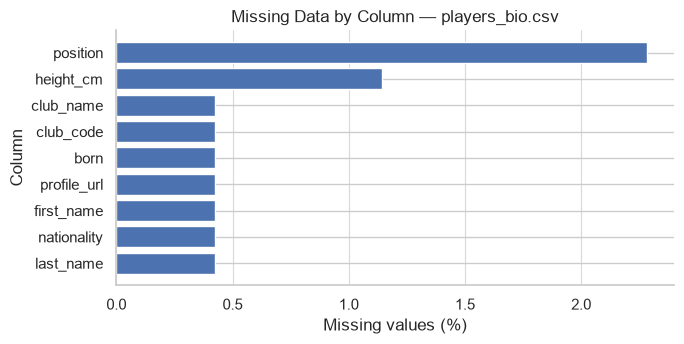

Saved figure: outputs\figures\missing_values_euroleague_points.png


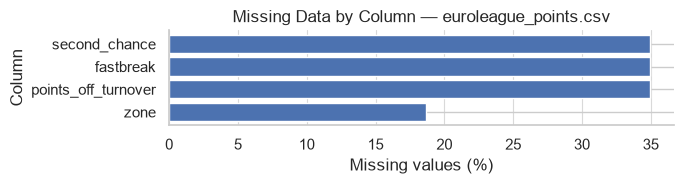

euroleague_players.csv: no columns with missing values -- chart skipped.


Saved figure: outputs\figures\missing_values_merged.png


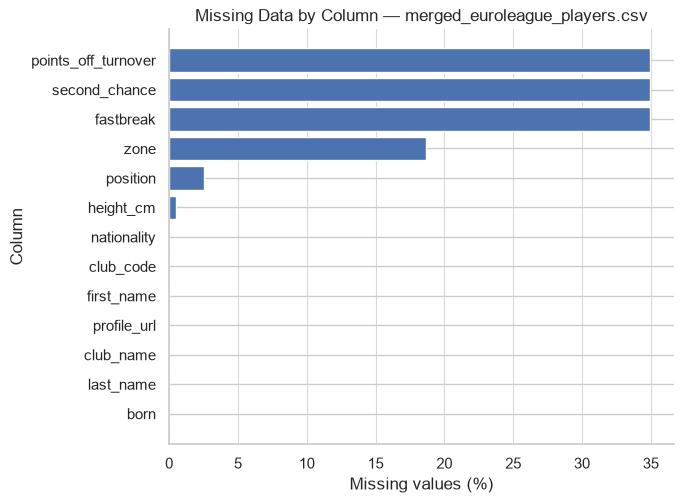

In [16]:
def plot_missing_percentages(tbl, dataset_name, filename):
    """Horizontal bar chart of missing % for columns with missing > 0, sorted descending."""
    nonzero = tbl[tbl["missing_count"] > 0].sort_values("missing_percentage")
    if nonzero.empty:
        print(f"{dataset_name}: no columns with missing values -- chart skipped.")
        return
    fig, ax = plt.subplots(figsize=(7, max(2, 0.4 * len(nonzero))))
    ax.barh(nonzero["column"], nonzero["missing_percentage"], color="#4C72B0")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("Column")
    ax.set_title(f"Missing Data by Column — {dataset_name}")
    ax.grid(axis="x", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


plot_missing_percentages(missing_tables["players_bio.csv"], "players_bio.csv",
                          "missing_values_players_bio.png")
plot_missing_percentages(missing_tables["euroleague_points.csv"], "euroleague_points.csv",
                          "missing_values_euroleague_points.png")
plot_missing_percentages(missing_tables["euroleague_players.csv"], "euroleague_players.csv",
                          "missing_values_euroleague_players.png")
plot_missing_percentages(missing_tables["merged_euroleague_players.csv"], "merged_euroleague_players.csv",
                          "missing_values_merged.png")

### 5.1 Columns Requiring Special Attention

The columns below were called out explicitly because they are candidates for later research
use (height, position, shot location/context) or describe data-collection quality
(`fetch_status`, `timestamp`).

In [17]:
attention_cols = {
    "players_bio.csv": ["height_cm", "position", "fetch_status"],
    "euroleague_points.csv": ["coord_x", "coord_y", "zone", "fastbreak", "second_chance",
                               "points_off_turnover", "timestamp"],
}
for dataset_name, cols in attention_cols.items():
    tbl = missing_tables[dataset_name]
    print(f"=== {dataset_name} ===")
    display(tbl[tbl["column"].isin(cols)][["column", "dtype", "missing_count", "missing_percentage",
                                            "unique_count"]])

=== players_bio.csv ===


,column,dtype,missing_count,missing_percentage,unique_count
0,position,str,54,2.285231,3
1,height_cm,float64,27,1.142615,54
13,fetch_status,str,0,0.000000,2


=== euroleague_points.csv ===


,column,dtype,missing_count,missing_percentage,unique_count
0,points_off_turnover,float64,263843,34.939383,2
1,fastbreak,float64,263843,34.939383,2
2,second_chance,float64,263843,34.939383,2
3,zone,str,141019,18.674427,10
16,coord_y,int64,0,0.000000,584
17,coord_x,int64,0,0.000000,711
23,timestamp,str,0,0.000000,455000


### 5.2 Event-Context Missingness by Season

`coord_x`, `coord_y`, `zone`, `fastbreak`, `second_chance`, and `points_off_turnover` are
context columns on the shot/action events. The purpose of this breakdown is to determine
whether missingness is concentrated in particular seasons, which would suggest a change in
how EuroLeague recorded event context over time rather than random missingness.

In [18]:
context_cols = ["coord_x", "coord_y", "zone", "fastbreak", "second_chance", "points_off_turnover"]
missing_by_season = (
    points_df.groupby("season_code")[context_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .round(2)
)
missing_by_season = missing_by_season.sort_index()
display(missing_by_season)
save_table(missing_by_season.reset_index(), "missing_by_season_event_context.csv")

,coord_x,coord_y,zone,fastbreak,second_chance,points_off_turnover
season_code,,,,,,
E2007,0.0,0.0,19.94,100.00,100.00,100.00
E2008,0.0,0.0,20.75,99.57,99.57,99.57
E2009,0.0,0.0,21.23,99.50,99.50,99.50
E2010,0.0,0.0,19.76,100.00,100.00,100.00
E2011,0.0,0.0,19.31,100.00,100.00,100.00
E2012,0.0,0.0,18.19,100.00,100.00,100.00
E2013,0.0,0.0,17.29,99.60,99.60,99.60
E2014,0.0,0.0,18.13,98.76,98.76,98.76
E2015,0.0,0.0,18.41,23.64,23.64,23.64


Saved table: outputs\tables\missing_by_season_event_context.csv  (rows=19)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/missing_by_season_event_context.csv')

Saved figure: outputs\figures\missing_by_season_event_context.png

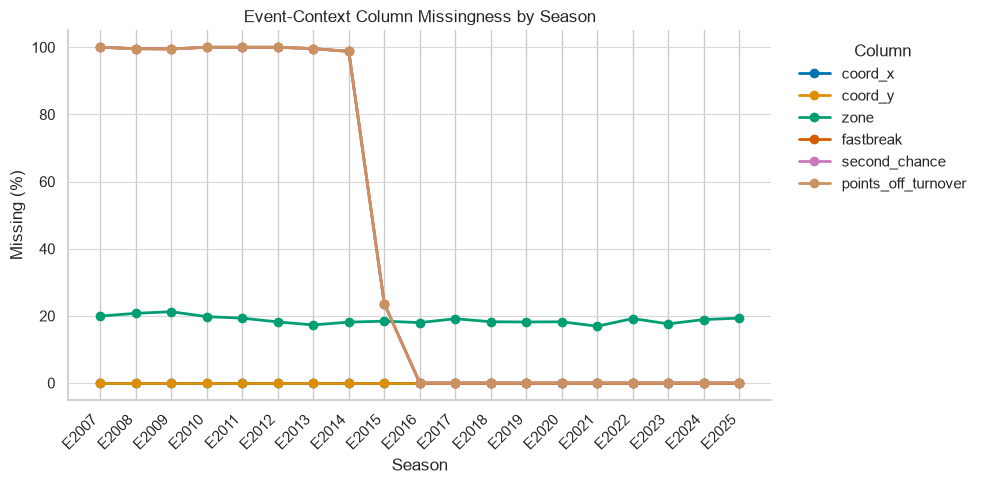

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("colorblind", n_colors=len(context_cols))
for color, col in zip(palette, context_cols):
    ax.plot(missing_by_season.index, missing_by_season[col], marker="o", label=col, color=color, linewidth=2)
ax.set_xlabel("Season")
ax.set_ylabel("Missing (%)")
ax.set_title("Event-Context Column Missingness by Season")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Column", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "missing_by_season_event_context.png")
plt.show()

**Findings — Section 5.** The full missing-value table for every file is in
`missing_values_summary.csv`; columns with at least one missing value are listed per file
above. `players_bio.csv` shows the previously reported pattern (missing `height_cm`,
`position`, and other biography fields concentrated in the 10 `not_found (http_404)` and a
further set of `ok`-status rows still missing `position`/`height_cm` — quantified precisely
in the tables above, not assumed). The event-context columns (`zone`, `fastbreak`,
`second_chance`, `points_off_turnover`) show missingness whose season-by-season pattern is
shown in `missing_by_season_event_context.csv` / the chart above — read the chart to judge
whether missingness is concentrated in specific seasons (a likely data-collection artifact)
or spread evenly. No values were imputed.

## 6. Data-Type and Range Validation

**What is being checked:** logical consistency of the season-level statistics (e.g.
`games_started <= games_played`, made shots <= attempted shots, percentages in [0, 1],
`total_rebounds == offensive_rebounds + defensive_rebounds`, per-game fields consistent with
totals divided by games played) and of the event data (coordinate ranges, action/action_id
consistency, game-time and score-field validity, and the usefulness of `timestamp`).

**Why it matters:** these checks catch data-entry or data-source errors that would silently
distort any statistic derived from these columns later (e.g. a per-36-minutes feature built
on top of a corrupted `minutes` value).

**How this may affect the research:** several of these columns (points, rebounds, assists,
steals, blocks, shooting splits) are exactly the kind of statistic likely to seed later
per-minute clustering features, so their integrity matters directly to the next task.

A numerical tolerance of **0.01** (one hundredth) is used for float-vs-derived-value
comparisons below, since per-game fields in the source file appear rounded to two decimals.

### 6.1 Season-Level Statistics (`euroleague_players.csv`)

In [20]:
TOLERANCE = 0.01
range_results = []

# Negative values where logically impossible
nonneg_cols = ["games_played", "games_started", "minutes", "points", "two_points_made",
               "two_points_attempted", "three_points_made", "three_points_attempted",
               "free_throws_made", "free_throws_attempted", "offensive_rebounds",
               "defensive_rebounds", "total_rebounds", "assists", "steals", "turnovers",
               "blocks_favour", "blocks_against", "fouls_committed", "fouls_received"]
for col in nonneg_cols:
    mask = players_df[col] < 0
    res = range_check(players_df, mask, "euroleague_players.csv", f"{col} < 0",
                       ["season_player_id", "player", col])
    range_results.append(res)

[euroleague_players.csv] games_played < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] games_started < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] minutes < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] points < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] two_points_made < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] two_points_attempted < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] three_points_made < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] three_points_attempted < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] free_throws_made < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] free_throws_attempted < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] offensive_rebounds < 0: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] defensive_rebounds < 0: 0 violations (0.0000% of 6307 rows)
[euroleague

In [21]:
mask = players_df["games_started"] > players_df["games_played"]
range_results.append(range_check(players_df, mask, "euroleague_players.csv",
                                  "games_started > games_played",
                                  ["season_player_id", "player", "games_started", "games_played"]))

for made, att in [("two_points_made", "two_points_attempted"),
                   ("three_points_made", "three_points_attempted"),
                   ("free_throws_made", "free_throws_attempted")]:
    mask = players_df[made] > players_df[att]
    range_results.append(range_check(players_df, mask, "euroleague_players.csv",
                                      f"{made} > {att}",
                                      ["season_player_id", "player", made, att]))

for pct_col in ["two_points_percentage", "three_points_percentage", "free_throws_percentage"]:
    mask = (players_df[pct_col] < 0) | (players_df[pct_col] > 1)
    range_results.append(range_check(players_df, mask, "euroleague_players.csv",
                                      f"{pct_col} outside [0, 1]",
                                      ["season_player_id", "player", pct_col]))

mask = players_df["minutes"] <= 0
range_results.append(range_check(players_df, mask, "euroleague_players.csv", "minutes <= 0",
                                  ["season_player_id", "player", "minutes", "games_played"]))

mask = players_df["games_played"] <= 0
range_results.append(range_check(players_df, mask, "euroleague_players.csv", "games_played <= 0",
                                  ["season_player_id", "player", "games_played", "minutes"]))

[euroleague_players.csv] games_started > games_played: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] two_points_made > two_points_attempted: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] three_points_made > three_points_attempted: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] free_throws_made > free_throws_attempted: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] two_points_percentage outside [0, 1]: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] three_points_percentage outside [0, 1]: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] free_throws_percentage outside [0, 1]: 0 violations (0.0000% of 6307 rows)
[euroleague_players.csv] minutes <= 0: 303 violations (4.8042% of 6307 rows)


,season_player_id,player,minutes,games_played
3771,E2011_P003412_BAM,"MONSE, STEVEN",0.0,0
4581,E2008_PLDH_LJU,"RADOJEVIC, DEJAN",0.0,0
2194,E2012_P002334_BER,"HERWIG, DAVID",0.0,0
4926,E2020_P010327_RED,"SARANOVIC, NIKOLA",0.0,0
1067,E2008_PLVW_SIE,"COURNOOH, DAVID",0.0,0


[euroleague_players.csv] games_played <= 0: 302 violations (4.7883% of 6307 rows)


,season_player_id,player,games_played,minutes
3771,E2011_P003412_BAM,"MONSE, STEVEN",0,0.0
4581,E2008_PLDH_LJU,"RADOJEVIC, DEJAN",0,0.0
2194,E2012_P002334_BER,"HERWIG, DAVID",0,0.0
4926,E2020_P010327_RED,"SARANOVIC, NIKOLA",0,0.0
1067,E2008_PLVW_SIE,"COURNOOH, DAVID",0,0.0


In [22]:
mask = (players_df["total_rebounds"] !=
        players_df["offensive_rebounds"] + players_df["defensive_rebounds"])
range_results.append(range_check(players_df, mask, "euroleague_players.csv",
                                  "total_rebounds != offensive_rebounds + defensive_rebounds",
                                  ["season_player_id", "player", "offensive_rebounds",
                                   "defensive_rebounds", "total_rebounds"]))

[euroleague_players.csv] total_rebounds != offensive_rebounds + defensive_rebounds: 0 violations (0.0000% of 6307 rows)


In [23]:
# Per-game consistency checks, restricted to rows with games_played > 0 (division is undefined
# otherwise); rows with games_played == 0 were already reported above.
has_games = players_df["games_played"] > 0
subset = players_df.loc[has_games]

expected_mpg = subset["minutes"] / subset["games_played"]
mask_mpg = (subset["minutes_per_game"] - expected_mpg).abs() > TOLERANCE
res = range_check(subset, mask_mpg, "euroleague_players.csv",
                   f"minutes_per_game != minutes/games_played (tolerance={TOLERANCE})",
                   ["season_player_id", "player", "minutes", "games_played", "minutes_per_game"])
range_results.append(res)

per_game_pairs = [
    ("points", "points_per_game"), ("assists", "assists_per_game"),
    ("total_rebounds", "total_rebounds_per_game"), ("steals", "steals_per_game"),
    ("turnovers", "turnovers_per_game"), ("blocks_favour", "blocks_favour_per_game"),
    ("valuation", "valuation_per_game"),
]
for total_col, pg_col in per_game_pairs:
    expected = subset[total_col] / subset["games_played"]
    mask = (subset[pg_col] - expected).abs() > TOLERANCE
    res = range_check(subset, mask, "euroleague_players.csv",
                       f"{pg_col} != {total_col}/games_played (tolerance={TOLERANCE})",
                       ["season_player_id", "player", total_col, "games_played", pg_col])
    range_results.append(res)

range_check_summary = pd.DataFrame(range_results)
display(range_check_summary)
save_table(range_check_summary, "range_check_summary_euroleague_players.csv")

for _, row in range_check_summary.iterrows():
    if row["n_violations"] > 0:
        sev = "critical" if row["pct_violations"] > 5 else "warning"
        log_issue(sev, "euroleague_players.csv", row["check"],
                  f"Range/consistency check failed: {row['check']}",
                  int(row["n_violations"]), row["pct_violations"], row.get("example", ""),
                  "Review affected rows before using this column as a clustering feature.")

[euroleague_players.csv] minutes_per_game != minutes/games_played (tolerance=0.01): 462 violations (7.6936% of 6005 rows)


,season_player_id,player,minutes,games_played,minutes_per_game
2899,E2022_P010185_ZAL,"KRIVAS, MOTIEJUS",2.2,2,1.11
377,E2012_P004170_IST,"BATUK, BIRKAN",33.6,2,16.82
579,E2007_P000009_MAD,"BOGDANOVIC, BOJAN",1.8,1,1.78
2872,E2015_P004096_IST,"KOSUT, EMIRCAN",1.5,1,1.48
1522,E2010_P000932_ULK,"EROGLU, ERBIL",11.5,2,5.78


[euroleague_players.csv] points_per_game != points/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] assists_per_game != assists/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] total_rebounds_per_game != total_rebounds/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] steals_per_game != steals/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] turnovers_per_game != turnovers/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] blocks_favour_per_game != blocks_favour/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)
[euroleague_players.csv] valuation_per_game != valuation/games_played (tolerance=0.01): 0 violations (0.0000% of 6005 rows)


,dataset,check,n_violations,pct_violations,example
0,euroleague_players.csv,games_played < 0,0,0.000000,
1,euroleague_players.csv,games_started < 0,0,0.000000,
2,euroleague_players.csv,minutes < 0,0,0.000000,
3,euroleague_players.csv,points < 0,0,0.000000,
4,euroleague_players.csv,two_points_made < 0,0,0.000000,
5,euroleague_players.csv,two_points_attempted < 0,0,0.000000,
6,euroleague_players.csv,three_points_made < 0,0,0.000000,
7,euroleague_players.csv,three_points_attempted < 0,0,0.000000,
8,euroleague_players.csv,free_throws_made < 0,0,0.000000,
9,euroleague_players.csv,free_throws_attempted < 0,0,0.000000,


Saved table: outputs\tables\range_check_summary_euroleague_players.csv  (rows=38)


### 6.2 Event Data (`euroleague_points.csv`)

In [24]:
coord_stats = points_df[["coord_x", "coord_y"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
)
coord_stats.loc["missing_pct"] = [
    100 * points_df["coord_x"].isna().mean(), 100 * points_df["coord_y"].isna().mean()
]
display(coord_stats)
save_table(coord_stats.reset_index().rename(columns={"index": "statistic"}), "coordinate_stats.csv")

,coord_x,coord_y
count,755145.000000,755145.000000
mean,-0.989350,230.414074
std,300.133554,255.282829
min,-740.000000,-156.000000
1%,-690.000000,-31.000000
5%,-570.000000,-1.000000
25%,-112.000000,12.000000
50%,-1.000000,119.000000
75%,112.000000,426.000000
95%,570.000000,715.000000


Saved table: outputs\tables\coordinate_stats.csv  (rows=13)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/coordinate_stats.csv')

Saved figure: outputs\figures\coordinate_distributions.png


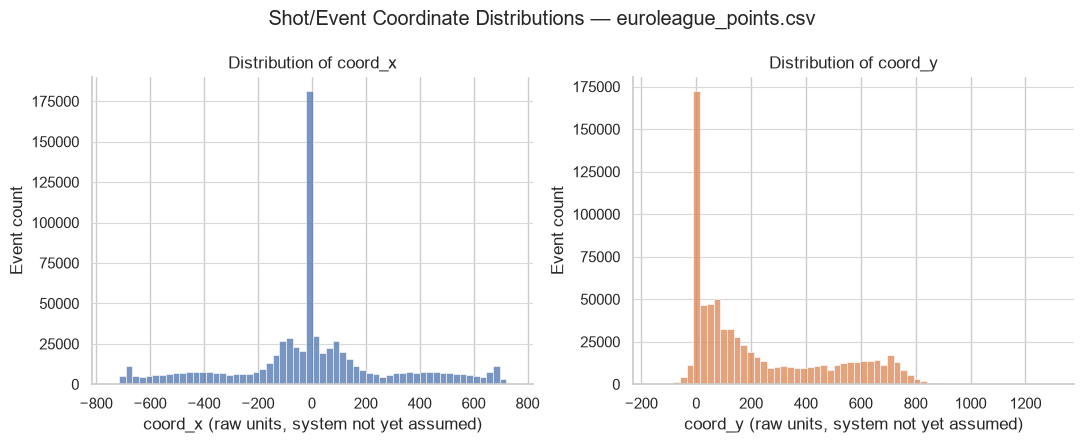

Note: the valid coordinate system (units, origin, court orientation) is not assumed here -- it is left as an open question for the next task, informed by the observed ranges and percentiles above.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(points_df["coord_x"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of coord_x")
axes[0].set_xlabel("coord_x (raw units, system not yet assumed)")
axes[0].set_ylabel("Event count")
sns.histplot(points_df["coord_y"], bins=60, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of coord_y")
axes[1].set_xlabel("coord_y (raw units, system not yet assumed)")
axes[1].set_ylabel("Event count")
for ax in axes:
    ax.grid(axis="y", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
fig.suptitle("Shot/Event Coordinate Distributions — euroleague_points.csv")
fig.tight_layout()
save_figure(fig, "coordinate_distributions.png")
plt.show()
print("Note: the valid coordinate system (units, origin, court orientation) is not assumed "
      "here -- it is left as an open question for the next task, informed by the observed "
      "ranges and percentiles above.")

In [26]:
distinct_actions = sorted(points_df["action"].dropna().unique().tolist())
distinct_action_ids = sorted(points_df["action_id"].dropna().unique().tolist())
print(f"Distinct action values ({len(distinct_actions)}): {distinct_actions}")
print(f"Distinct action_id values ({len(distinct_action_ids)}): {distinct_action_ids}")

action_crosstab = pd.crosstab(points_df["action_id"], points_df["action"])
display(action_crosstab)
save_table(action_crosstab.reset_index(), "action_id_action_crosstab.csv")

action_id_to_desc = points_df.groupby("action_id")["action"].nunique()
desc_to_action_id = points_df.groupby("action")["action_id"].nunique()
n_id_multi_desc = int((action_id_to_desc > 1).sum())
n_desc_multi_id = int((desc_to_action_id > 1).sum())
print(f"\naction_id values mapping to more than one action description: {n_id_multi_desc}")
print(f"action descriptions mapping to more than one action_id: {n_desc_multi_id}")
if n_desc_multi_id > 0:
    for desc, ids in desc_to_action_id[desc_to_action_id > 1].items():
        matching_ids = points_df.loc[points_df["action"] == desc, "action_id"].unique()
        print(f"  '{desc}' -> action_id values: {sorted(matching_ids)}")

Distinct action values (8): ['Dunk', 'Free Throw In', 'Layup Made', 'Missed Layup', 'Missed Three Pointer', 'Missed Two Pointer', 'Three Pointer', 'Two Pointer']
Distinct action_id values (10): ['2FGA', '2FGAB', '2FGM', '3FGA', '3FGAB', '3FGM', 'DUNK', 'FTM', 'LAYUPATT', 'LAYUPMD']


action,Dunk,Free Throw In,Layup Made,Missed Layup,Missed Three Pointer,Missed Two Pointer,Three Pointer,Two Pointer
action_id,,,,,,,,
2FGA,0,0,0,0,0,147240,0,0
2FGAB,0,0,0,0,0,5897,0,0
2FGM,0,0,0,0,0,0,0,160519
3FGA,0,0,0,0,148262,0,0,0
3FGAB,0,0,0,0,687,0,0,0
3FGM,0,0,0,0,0,0,84421,0
DUNK,7079,0,0,0,0,0,0,0
FTM,0,140926,0,0,0,0,0,0
LAYUPATT,0,0,0,26029,0,0,0,0


Saved table: outputs\tables\action_id_action_crosstab.csv  (rows=10)



action_id values mapping to more than one action description: 0
action descriptions mapping to more than one action_id: 2
  'Missed Three Pointer' -> action_id values: ['3FGA', '3FGAB']


  'Missed Two Pointer' -> action_id values: ['2FGA', '2FGAB']


In [27]:
points_by_action = points_df.groupby(["action", "action_id"])["points"].agg(["min", "max", "mean", "count"])
display(points_by_action)

min  max  mean   count
action               action_id                        
Dunk                 DUNK         2    2   2.0    7079
Free Throw In        FTM          1    1   1.0  140926
Layup Made           LAYUPMD      2    2   2.0   34085
Missed Layup         LAYUPATT     0    0   0.0   26029
Missed Three Pointer 3FGA         0    0   0.0  148262
                     3FGAB        0    0   0.0     687
Missed Two Pointer   2FGA         0    0   0.0  147240
                     2FGAB        0    0   0.0    5897
Three Pointer        3FGM         3    3   3.0   84421
Two Pointer          2FGM         2    2   2.0  160519

### 6.3 Game Time, Console, and Score Fields

In [28]:
print("minute range:", points_df["minute"].min(), "-", points_df["minute"].max())
print()
print("console value counts:")
display(points_df["console"].value_counts().head(20))

# console is expected to look like MM:SS -- flag anything that does not match that pattern
console_pattern = points_df["console"].astype(str).str.match(r"^\d{1,2}:\d{2}$")
n_malformed_console = int((~console_pattern).sum())
print(f"\nRows where 'console' does not match the MM:SS pattern: {n_malformed_console} "
      f"({100 * n_malformed_console / len(points_df):.4f}%)")
if n_malformed_console > 0:
    display(points_df.loc[~console_pattern, ["game_point_id", "console"]]
            .sample(min(5, n_malformed_console), random_state=RANDOM_STATE))

minute range: 1 - 60

console value counts:


console
00:00    19833
01:00    15270
02:00    13200
03:00    12797
04:00    12401
05:00    12291
06:00    12182
07:00    12094
08:00    11875
09:00    11259
00:01     5147
00:02     3323
00:03     2578
00:04     1940
00:05     1701
00:06     1499
00:07     1338
09:40     1284
00:27     1279
00:30     1273
Name: count, dtype: int64


Rows where 'console' does not match the MM:SS pattern: 14 (0.0019%)


,game_point_id,console
571585,E2022_208_281,00:-1
601323,E2023_078_262,00:-1
342217,E2017_067_564,00:-1
655011,E2024_099_392,00:-1
504135,E2021_052_103,00:-1


In [29]:
neg_score = (points_df["points_a"] < 0) | (points_df["points_b"] < 0)
print(f"Rows with negative points_a or points_b: {int(neg_score.sum())}")

# Score progression within a game should be monotonically non-decreasing for each team.
def score_decreases(group):
    g = group.sort_values("number_of_play")
    dec_a = (g["points_a"].diff() < 0).sum()
    dec_b = (g["points_b"].diff() < 0).sum()
    return pd.Series({"dec_a": dec_a, "dec_b": dec_b})

score_check = points_df.groupby("game_id").apply(score_decreases, include_groups=False)
games_with_decrease = score_check[(score_check["dec_a"] > 0) | (score_check["dec_b"] > 0)]
print(f"Games with at least one score decrease in points_a or points_b: {len(games_with_decrease)} "
      f"of {points_df['game_id'].nunique()} games")
if len(games_with_decrease) > 0:
    display(games_with_decrease.sample(min(5, len(games_with_decrease)), random_state=RANDOM_STATE))

log_issue("info" if len(games_with_decrease) == 0 else "warning", "euroleague_points.csv",
          "points_a/points_b", "Games where cumulative score decreases within number_of_play order",
          len(games_with_decrease), 100 * len(games_with_decrease) / points_df["game_id"].nunique(),
          "", "Review flagged games manually; do not auto-correct scores.")

Rows with negative points_a or points_b: 0


Games with at least one score decrease in points_a or points_b: 1340 of 5039 games


,dec_a,dec_b
game_id,,
E2018_232,1,1
E2023_101,0,1
E2018_126,1,1
E2018_150,1,1
E2017_072,1,1


### 6.4 `timestamp`

In [30]:
print("Most frequent timestamp values:")
display(points_df["timestamp"].value_counts().head(10))

is_1970 = points_df["timestamp"].astype(str).str.startswith("1970-01-01")
n_1970 = int(is_1970.sum())
print(f"\nRows with a 1970-01-01 timestamp: {n_1970} ({100 * n_1970 / len(points_df):.2f}%)")

log_issue("warning", "euroleague_points.csv", "timestamp",
          "Large share of rows carry a 1970-01-01 epoch placeholder rather than a real game date",
          n_1970, 100 * n_1970 / len(points_df),
          points_df.loc[is_1970, "timestamp"].iloc[0] if n_1970 else "",
          "Do not rely on timestamp as a game-date field without further source verification; "
          "game date, if needed, should instead be derived from game_id/game/round/season_code.")

Most frequent timestamp values:


timestamp
1970-01-01             270790
1970-01-01 00:00:00     21501
2024-04-11 18:30:29         4
2016-11-03 20:34:17         3
2017-01-27 19:28:09         3
2017-11-14 20:33:37         3
2017-11-23 21:19:16         3
2018-03-30 17:03:31         3
2018-10-25 19:04:25         3
2018-11-16 20:04:09         3
Name: count, dtype: int64


Rows with a 1970-01-01 timestamp: 292291 (38.71%)


**Findings — Section 6.** All season-level range/consistency checks are summarized in
`range_check_summary_euroleague_players.csv`, with the violation count and percentage for
each check and example rows shown above where violations exist. Coordinate percentiles and
a histogram characterize the observed `coord_x`/`coord_y` ranges without assuming a
coordinate system. The `action`/`action_id` cross-tabulation shows whether every action code
maps to exactly one description and vice versa (any many-to-one case is reported by name
above, together with the affected rows in the crosstab). `console` was checked against an
MM:SS pattern rather than assumed valid. Score-progression checks flag any game where
`points_a`/`points_b` decreases, without correcting it. `timestamp`'s heavy concentration on
the `1970-01-01` epoch value is quantified above and logged as a warning: it is not deleted,
but should not be treated as a usable game-date field without further verification.

## 7. Categorical Distributions

**What is being checked:** frequency counts for the main categorical fields across the
files (`season_code`, `team_id`, `phase`, `action`, `action_id`, `zone`, `position`,
`fetch_status`). High-cardinality fields report their unique count plus the 20 most frequent
values; low-cardinality fields (`position`, `fetch_status`) are reported in full.

**Why it matters:** categorical distributions reveal coverage gaps (e.g. a team code that
appears once, a phase value that is a near-duplicate of another) and give a first read on
class balance for fields that may later inform interpretation (never model input, in the
case of `position`).

**How this may affect the research:** `position` distribution matters for later comparing
discovered clusters against traditional positions — but it is not used as a feature here or
later during clustering.

In [31]:
def frequency_summary(series, name, top_n=20):
    """Print unique-value count and the top-N most frequent values for a categorical column."""
    n_unique = series.nunique(dropna=True)
    print(f"--- {name}: {n_unique} unique value(s) ---")
    display(series.value_counts(dropna=False).head(top_n).rename("count").to_frame())
    return n_unique


high_cardinality = [
    (points_df["team_id"], "team_id (euroleague_points.csv)"),
    (points_df["action"], "action"),
    (points_df["action_id"], "action_id"),
    (points_df["zone"], "zone"),
]
for series, name in high_cardinality:
    frequency_summary(series, name)

--- team_id (euroleague_points.csv): 66 unique value(s) ---


,count
team_id,
MAD,45801
OLY,44184
BAR,43463
PAN,42578
BAS,41184
TEL,41184
ULK,40530
IST,40444
ZAL,37859


--- action: 8 unique value(s) ---


,count
action,
Two Pointer,160519
Missed Two Pointer,153137
Missed Three Pointer,148949
Free Throw In,140926
Three Pointer,84421
Layup Made,34085
Missed Layup,26029
Dunk,7079


--- action_id: 10 unique value(s) ---


,count
action_id,
2FGM,160519
3FGA,148262
2FGA,147240
FTM,140926
3FGM,84421
LAYUPMD,34085
LAYUPATT,26029
DUNK,7079
2FGAB,5897


--- zone: 10 unique value(s) ---


,count
zone,
NaN,141019
B,112309
I,109286
H,107844
C,102602
D,50881
E,38479
G,29937
A,29195


In [32]:
low_cardinality = [
    (points_df["season_code"], "season_code (euroleague_points.csv)"),
    (points_df["phase"], "phase"),
]
for series, name in low_cardinality:
    frequency_summary(series, name, top_n=30)

--- season_code (euroleague_points.csv): 19 unique value(s) ---


,count
season_code,
E2025,64137
E2024,51193
E2023,50159
E2022,49409
E2020,48256
E2021,43555
E2017,39421
E2016,38926
E2018,38916


--- phase: 7 unique value(s) ---


,count
phase,
REGULAR SEASON,598868
TOP 16,99019
PLAYOFFS,38997
FINAL FOUR,10822
PLAY OFF,3885
TOP SIXTEEN,2198
PLAY-IN,1356


### 7.1 `position` (traditional label — interpretation only, never a clustering feature)

In [33]:
position_counts = bio_df["position"].value_counts(dropna=False)
position_pct = 100 * position_counts / len(bio_df)
position_summary = pd.DataFrame({"count": position_counts, "percentage": position_pct.round(2)})
display(position_summary)

n_missing_position = int(bio_df["position"].isna().sum())
print(f"\nMissing position: {n_missing_position} ({100 * n_missing_position / len(bio_df):.2f}%)")
print("Reminder: position values are reported here for descriptive/interpretive use only. "
      "They are NOT recoded, combined, or used as a clustering input.")

,count,percentage
position,,
Guard,979,41.43
Forward,838,35.46
Center,492,20.82
NaN,54,2.29



Missing position: 54 (2.29%)
Reminder: position values are reported here for descriptive/interpretive use only. They are NOT recoded, combined, or used as a clustering input.


### 7.2 `fetch_status`

In [34]:
fetch_status_counts = bio_df["fetch_status"].value_counts(dropna=False)
display(fetch_status_counts.rename("count").to_frame())

# Association between fetch_status and missing height/position
assoc = bio_df.assign(
    missing_height=bio_df["height_cm"].isna(),
    missing_position=bio_df["position"].isna(),
).groupby("fetch_status")[["missing_height", "missing_position"]].sum()
assoc["n_rows"] = bio_df["fetch_status"].value_counts()
display(assoc)

,count
fetch_status,
ok,2353
not_found (http_404),10


,missing_height,missing_position,n_rows
fetch_status,,,
not_found (http_404),10,10,10
ok,17,44,2353


**Findings — Section 7.** Frequency tables for the requested categorical fields are shown
above; high-cardinality fields (`team_id`, `action`, `action_id`, `zone`) are limited to
their top-20 most frequent values plus a reported unique-value count, while `season_code`,
`phase`, `position`, and `fetch_status` are shown in full given their low cardinality.
`position` is reported strictly for later interpretive/comparison use — it is not recoded or
combined here, and it will not be used as a training feature. The `fetch_status` cross-check
above shows whether the 27 missing-height and 54 missing-position rows previously reported
concentrate in the `not_found (http_404)` status, or extend into `ok`-status rows as well —
read directly from the `assoc` table.

## 8. Height Audit

**What is being checked:** descriptive statistics for `height_cm` (count, missing,
central tendency, spread, percentiles, extremes), a histogram, and a descriptive-only
comparison of height by traditional position.

**Why it matters:** height is a physical attribute likely to be included as a clustering
feature later (distinct from position). Its distribution and any implausible extreme values
need to be known and documented before that decision is made.

**How this may affect the research:** the position-height comparison here is explicitly
**descriptive/interpretive**, not a modeling step — traditional position is never used as a
training feature in this project.

In [35]:
height = bio_df["height_cm"]
height_stats = height.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
height_summary = pd.DataFrame({
    "statistic": ["count", "missing_count", "missing_percentage", "mean", "median", "std",
                  "min", "max", "p1", "p5", "p25", "p50", "p75", "p95", "p99"],
    "value": [
        int(height.count()), int(height.isna().sum()), round(100 * height.isna().mean(), 2),
        round(height.mean(), 2), round(height.median(), 2), round(height.std(), 2),
        height.min(), height.max(),
        height_stats["1%"], height_stats["5%"], height_stats["25%"],
        height_stats["50%"], height_stats["75%"], height_stats["95%"], height_stats["99%"],
    ],
})
display(height_summary)
save_table(height_summary, "height_audit_summary.csv")

,statistic,value
0,count,2336.00
1,missing_count,27.00
2,missing_percentage,1.14
3,mean,194.10
4,median,199.50
5,std,32.18
6,min,0.00
7,max,229.00
8,p1,0.00
9,p5,181.75


Saved table: outputs\tables\height_audit_summary.csv  (rows=15)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/height_audit_summary.csv')

Saved figure: outputs\figures\height_distribution.png


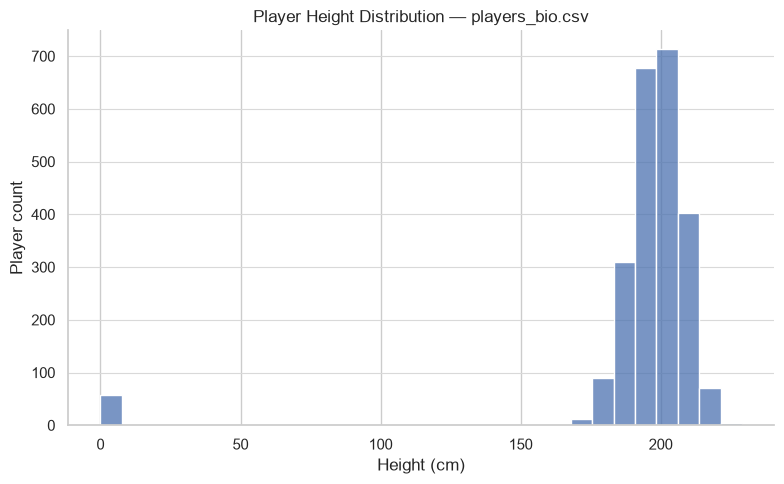

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(height.dropna(), bins=30, color="#4C72B0", ax=ax)
ax.set_title("Player Height Distribution — players_bio.csv")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Player count")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "height_distribution.png")
plt.show()

In [37]:
# Extreme values flagged for review only -- not removed.
low_cut, high_cut = height.quantile(0.01), height.quantile(0.99)
extreme = bio_df.loc[(height < low_cut) | (height > high_cut),
                      ["player_id", "first_name", "last_name", "height_cm", "position"]]
print(f"Players with height outside the 1st-99th percentile band ({low_cut:.0f}-{high_cut:.0f} cm): "
      f"{len(extreme)}")
display(extreme.sort_values("height_cm"))

extreme_example = (
    f"{extreme.iloc[0]['last_name']} ({extreme.iloc[0]['height_cm']} cm)" if len(extreme) else ""
)
log_issue("info", "players_bio.csv", "height_cm",
          "Players with height outside the 1st-99th percentile band (flagged for review, not removed)",
          len(extreme), 100 * len(extreme) / height.count(), extreme_example,
          "Manual review before modeling.")

Players with height outside the 1st-99th percentile band (0-217 cm): 20


,player_id,first_name,last_name,height_cm,position
65,P004327,KOSTIANTYN,ANIKIIENKO,218.0,Center
567,P001398,ROMAIN,DUPORT,218.0,Center
615,P008811,MOUSTAPHA,FALL,218.0,Center
1679,PLHK,TIBOR,PLEISS,218.0,Center
2305,PTFG,LOREN,WOODS,218.0,Center
2130,PTFW,JAKE,TSAKALIDIS,218.0,Center
1719,P004834,ARTEM,PUSTOVYI,219.0,Center
336,P002256,DUSAN,CANTEKIN,219.0,Center
2055,P005791,WALTER,TAVARES,220.0,Center
2033,P012116,LUIGI,SUIGO,220.0,Center


,count,mean,median,std,min,max
position,,,,,,
Center,491,208.1,209.0,16.9,0.0,229.0
Forward,830,199.6,203.0,23.5,0.0,220.0
Guard,978,188.3,191.0,23.4,0.0,206.0
NaN,37,37.4,0.0,78.6,0.0,213.0


Saved figure: outputs\figures\height_by_position_descriptive.png


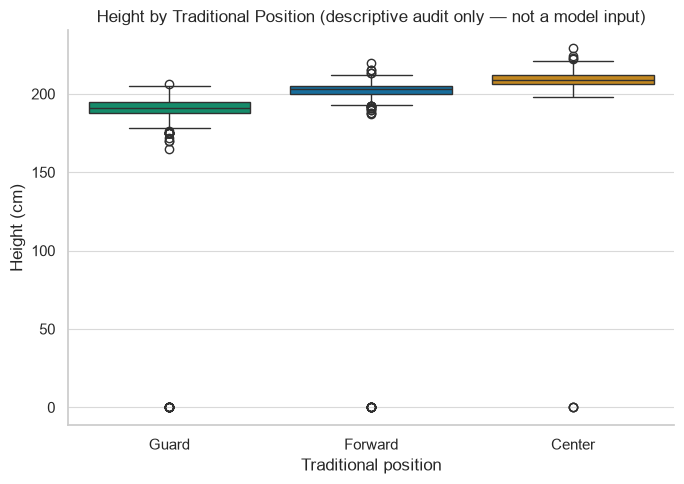

In [38]:
# Descriptive-only comparison by traditional position -- NOT a modeling step.
height_by_position = bio_df.groupby("position", dropna=False)["height_cm"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)
display(height_by_position)

fig, ax = plt.subplots(figsize=(7, 5))
order = ["Guard", "Forward", "Center"]
present_order = [p for p in order if p in bio_df["position"].dropna().unique()]
sns.boxplot(data=bio_df.dropna(subset=["position"]), x="position", y="height_cm",
            order=present_order, hue="position", palette="colorblind", legend=False, ax=ax)
ax.set_title("Height by Traditional Position (descriptive audit only — not a model input)")
ax.set_xlabel("Traditional position")
ax.set_ylabel("Height (cm)")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, "height_by_position_descriptive.png")
plt.show()

**Findings — Section 8.** Height summary statistics and percentiles are in the table above
and exported to `height_audit_summary.csv`. Extreme values (outside the 1st-99th percentile
band) are listed for manual review, not removed. The position-height comparison shows the
expected ordering (Centers tallest, Guards shortest) as a descriptive fact about the data —
this comparison is not, and will not become, part of the clustering feature set.

## 9. Season and Player Coverage

**What is being checked:** per-season row/player/team/game counts for the season-level and
event-level files, the set of seasons present versus any gaps, and — critically — a
`season_code + player_id + team_id` comparison between `euroleague_players.csv` and
`euroleague_points.csv` in both directions, including a characterization of the 459
season-level observations previously reported to have no matching event data.

**Why it matters:** the two files are expected to describe the same underlying seasons and
largely the same players, but the initial feasibility analysis already found a coverage gap
(5,848 event-side player-season-team combinations vs. 6,307 season-level rows). Understanding
*why* observations fall on only one side is necessary before deciding how to build the final
modeling table.

**How this may affect the research:** if event-only feature engineering is planned later,
the 459 statistics-only observations would be silently excluded unless explicitly handled —
this section documents them instead of removing them.

### 9.1 Per-Season Row / Player / Team / Game Counts

In [39]:
def season_coverage(df, name, has_games=True):
    agg = {"row_count": ("season_code", "size"),
           "unique_players": ("player_id", "nunique"),
           "unique_teams": ("team_id", "nunique")}
    if has_games and "game_id" in df.columns:
        agg["unique_games"] = ("game_id", "nunique")
    out = df.groupby("season_code").agg(**agg).reset_index()
    out.insert(0, "dataset", name)
    return out


players_season_cov = season_coverage(players_df, "euroleague_players.csv", has_games=False)
points_season_cov = season_coverage(points_df, "euroleague_points.csv", has_games=True)

display(players_season_cov)
display(points_season_cov)

season_coverage_summary = pd.concat([players_season_cov, points_season_cov], ignore_index=True)
save_table(season_coverage_summary, "season_coverage_summary.csv")

,dataset,season_code,row_count,unique_players,unique_teams
0,euroleague_players.csv,E2007,376,373,24
1,euroleague_players.csv,E2008,371,370,24
2,euroleague_players.csv,E2009,368,365,24
3,euroleague_players.csv,E2010,363,360,24
4,euroleague_players.csv,E2011,363,359,24
5,euroleague_players.csv,E2012,365,361,24
6,euroleague_players.csv,E2013,369,365,24
7,euroleague_players.csv,E2014,375,372,24
8,euroleague_players.csv,E2015,367,364,24
9,euroleague_players.csv,E2016,261,259,16


,dataset,season_code,row_count,unique_players,unique_teams,unique_games
0,euroleague_points.csv,E2007,33980,338,24,231
1,euroleague_points.csv,E2008,27609,335,24,188
2,euroleague_points.csv,E2009,27187,329,24,188
3,euroleague_points.csv,E2010,27792,326,24,189
4,euroleague_points.csv,E2011,27738,326,24,188
5,euroleague_points.csv,E2012,36806,332,24,253
6,euroleague_points.csv,E2013,36863,338,24,253
7,euroleague_points.csv,E2014,37935,346,24,251
8,euroleague_points.csv,E2015,37256,344,24,250
9,euroleague_points.csv,E2016,38926,238,16,259


Saved table: outputs\tables\season_coverage_summary.csv  (rows=38)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/season_coverage_summary.csv')

In [40]:
def season_range_report(df, name):
    seasons = sorted(df["season_code"].unique())
    earliest, latest = seasons[0], seasons[-1]
    expected_years = list(range(int(earliest[1:]), int(latest[1:]) + 1))
    expected = {f"E{y}" for y in expected_years}
    missing = sorted(expected - set(seasons))
    print(f"{name}: earliest={earliest}, latest={latest}, seasons_present={len(seasons)}, "
          f"missing_within_range={missing if missing else 'none'}")
    return seasons


players_seasons = season_range_report(players_df, "euroleague_players.csv")
points_seasons = season_range_report(points_df, "euroleague_points.csv")
bio_has_season = "season_code" not in bio_df.columns
print(f"\nplayers_bio.csv has no season_code column (player-level granularity): {bio_has_season}")

euroleague_players.csv: earliest=E2007, latest=E2025, seasons_present=19, missing_within_range=none
euroleague_points.csv: earliest=E2007, latest=E2025, seasons_present=19, missing_within_range=none

players_bio.csv has no season_code column (player-level granularity): True


### 9.2 `euroleague_players.csv` vs. `euroleague_points.csv` — Player and Player-Season-Team Coverage

Comparisons below use the composite key `season_code + player_id + team_id`, as required —
not `player_id` alone, since the same player can appear for different teams.

In [41]:
# Player-level coverage (ignoring team/season) -- players present in one file but not the other.
players_in_stats = set(players_df["player_id"].unique())
players_in_events = set(points_df["player_id"].unique())

stats_only_players = players_in_stats - players_in_events
events_only_players = players_in_events - players_in_stats

print(f"Players in euroleague_players.csv but not in euroleague_points.csv: {len(stats_only_players)}")
print(f"Players in euroleague_points.csv but not in euroleague_players.csv: {len(events_only_players)}")

Players in euroleague_players.csv but not in euroleague_points.csv: 271
Players in euroleague_points.csv but not in euroleague_players.csv: 0


In [42]:
# Player-season-team level coverage using the composite key.
key_cols = ["season_code", "player_id", "team_id"]
stats_keys = players_df[key_cols].drop_duplicates()
event_keys = points_df[key_cols].drop_duplicates()

stats_vs_events = stats_keys.merge(event_keys, on=key_cols, how="outer", indicator=True)

stats_only = stats_vs_events[stats_vs_events["_merge"] == "left_only"]
events_only = stats_vs_events[stats_vs_events["_merge"] == "right_only"]
both = stats_vs_events[stats_vs_events["_merge"] == "both"]

print(f"Player-season-team combinations in stats only (no event data): {len(stats_only)}")
print(f"Player-season-team combinations in events only (no stats row): {len(events_only)}")
print(f"Player-season-team combinations in both: {len(both)}")
print(f"Total distinct combinations in euroleague_players.csv: {len(stats_keys)}")
print(f"Total distinct combinations in euroleague_points.csv: {len(event_keys)}")

print("\nDistribution of stats-only combinations by season:")
display(stats_only["season_code"].value_counts().sort_index())

print("\nDistribution of events-only combinations by season:")
if len(events_only) > 0:
    display(events_only["season_code"].value_counts().sort_index())
else:
    print("  (none)")

stats_only_example = (
    stats_only[["season_code", "player_id", "team_id"]].iloc[0].to_dict() if len(stats_only) else ""
)
log_issue("warning", "euroleague_players.csv vs euroleague_points.csv", "season_code+player_id+team_id",
          "Player-season-team combinations present in season-level stats but absent from event data",
          len(stats_only), 100 * len(stats_only) / len(stats_keys), stats_only_example,
          "Do not remove; document as an expected gap. Confirm cause (e.g. seasons/rounds not "
          "covered by the event scrape) before deciding whether these rows are usable in the "
          "final feature table.")

Player-season-team combinations in stats only (no event data): 459
Player-season-team combinations in events only (no stats row): 0
Player-season-team combinations in both: 5848
Total distinct combinations in euroleague_players.csv: 6307
Total distinct combinations in euroleague_points.csv: 5848

Distribution of stats-only combinations by season:


season_code
E2007    35
E2008    35
E2009    36
E2010    34
E2011    33
E2012    29
E2013    27
E2014    26
E2015    20
E2016    21
E2017    16
E2018    13
E2019    17
E2020    17
E2021    24
E2022    23
E2023    14
E2024    15
E2025    24
Name: count, dtype: int64


Distribution of events-only combinations by season:
  (none)


In [43]:
# Representative examples of the stats-only combinations, joined back to season-level detail.
stats_only_detail = players_df.merge(stats_only[key_cols], on=key_cols, how="inner")
print(f"Stats-only observations, detailed: {len(stats_only_detail)}")
display(stats_only_detail[["season_player_id", "season_code", "player_id", "player", "team_id",
                            "games_played", "minutes", "two_points_attempted",
                            "three_points_attempted"]]
        .sample(min(10, len(stats_only_detail)), random_state=RANDOM_STATE))

print("\nDescriptive summary of the stats-only observations:")
display(stats_only_detail[["games_played", "minutes", "two_points_attempted",
                            "three_points_attempted", "free_throws_attempted"]].describe())

print(f"\nDistinct players among stats-only observations: {stats_only_detail['player_id'].nunique()}")
print(f"Distinct teams among stats-only observations: {stats_only_detail['team_id'].nunique()}")
print(f"Distinct seasons among stats-only observations: {stats_only_detail['season_code'].nunique()}")

Stats-only observations, detailed: 459


,season_player_id,season_code,player_id,player,team_id,games_played,minutes,two_points_attempted,three_points_attempted
124,E2015_P006628_LMG,E2015,P006628,"FAUCHE, VINCENT",LMG,0,0.0,0,0
30,E2009_PLVI_TEL,E2009,PLVI,"BER AVEN, TOMER",TEL,1,23.2,0,0
199,E2010_P002872_PAN,E2010,P002872,"KARAMALEGOS, IOANNIS",PAN,1,0.6,0,0
438,E2010_PKPQ_SOP,E2010,PKPQ,"WITKA, ROBERT",SOP,1,2.0,0,0
154,E2025_P013555_MAD,E2025,P013555,"GRINVALDS, GUNARS",MAD,1,0.8,0,0
225,E2018_P007265_BAS,E2018,P007265,"KURUCS, ARTURS",BAS,0,0.0,0,0
405,E2008_P001184_JOV,E2008,P001184,"TOMAS, JOAN",JOV,0,0.0,0,0
296,E2014_P005828_KLA,E2014,P005828,"NACIUS, RAIDAS",KLA,1,4.1,0,0
222,E2022_P010824_ZAL,E2022,P010824,"KUBLICKAS, KAJUS",ZAL,1,0.2,0,0
75,E2013_PBVG_GSS,E2013,PBVG,"CESNAUSKIS, MANTAS",GSS,0,0.0,0,0



Descriptive summary of the stats-only observations:


,games_played,minutes,two_points_attempted,three_points_attempted,free_throws_attempted
count,459.000000,459.000000,459.0,459.0,459.000000
mean,0.494553,1.091285,0.0,0.0,0.004357
std,0.831603,3.013835,0.0,0.0,0.093352
min,0.000000,0.000000,0.0,0.0,0.000000
25%,0.000000,0.000000,0.0,0.0,0.000000
50%,0.000000,0.000000,0.0,0.0,0.000000
75%,1.000000,0.850000,0.0,0.0,0.000000
max,5.000000,29.200000,0.0,0.0,2.000000



Distinct players among stats-only observations: 406
Distinct teams among stats-only observations: 58
Distinct seasons among stats-only observations: 19


**Findings — Section 9.** Per-season row/player/team/game counts are in
`season_coverage_summary.csv`. Both files span the same 19-season range
(`E2007`-`E2025`) with no gaps within that range, per the season-range report above.
The player-season-team comparison independently reproduces the previously reported gap: the
`stats_only` count above (expected 459) is the set of season-level observations with no
matching event data — its size, season distribution, and descriptive characteristics
(minutes, games played, shot attempts) are shown directly above rather than assumed. These
observations are **not removed**; they are logged as a warning-level issue for review before
any feature-engineering step that depends on event-derived columns.

## 10. Biography Join Validation

**What is being checked:** two in-memory left joins — `euroleague_players` with
`players_bio` on `player_id`, and `euroleague_points` with `players_bio` on `player_id` —
using pandas' `validate` argument to assert the expected many-to-one cardinality, plus
match/unmatch counts and a check for whether either join duplicated rows from the left side.

**Why it matters:** later enrichment steps (height, position, nationality) depend on this
join behaving exactly as expected: every left-side row should gain biography fields without
being duplicated, since `players_bio.csv` is one row per player.

**How this may affect the research:** confirms whether biography enrichment can be trusted
to preserve row counts on both the season-level and event-level tables.

In [44]:
def bio_join_report(left_df, left_name, key="player_id"):
    """Left-join `left_df` with players_bio on `key`, validating m:1 cardinality, and report."""
    input_rows = len(left_df)
    merged = left_df.merge(
        bio_df, on=key, how="left", suffixes=("", "_bio"), indicator=True, validate="m:1"
    )
    output_rows = len(merged)
    matched = int((merged["_merge"] == "both").sum())
    unmatched = int((merged["_merge"] == "left_only").sum())
    unmatched_players = int(left_df.loc[~left_df[key].isin(bio_df[key]), key].nunique())
    row_count_preserved = output_rows == input_rows

    print(f"=== Join: {left_name} (left) + players_bio (right) on '{key}' ===")
    print(f"Input rows: {input_rows:,} | Output rows: {output_rows:,} | "
          f"Row count preserved (no fan-out): {row_count_preserved}")
    print(f"Matched: {matched:,} ({100 * matched / input_rows:.4f}%) | "
          f"Unmatched: {unmatched:,} ({100 * unmatched / input_rows:.4f}%) | "
          f"Unmatched distinct players: {unmatched_players}")
    if unmatched > 0:
        display(merged.loc[merged["_merge"] == "left_only", [key]].drop_duplicates()
                .sample(min(5, unmatched_players), random_state=RANDOM_STATE))

    return {
        "join_name": f"{left_name} + players_bio on {key}",
        "input_rows": input_rows,
        "output_rows": output_rows,
        "match_count": matched,
        "match_percentage": 100 * matched / input_rows,
        "unmatched_count": unmatched,
        "unmatched_unique_players": unmatched_players,
        "row_count_preserved": row_count_preserved,
    }


join_players_bio = bio_join_report(players_df, "euroleague_players.csv")
join_points_bio = bio_join_report(points_df, "euroleague_points.csv")

=== Join: euroleague_players.csv (left) + players_bio (right) on 'player_id' ===
Input rows: 6,307 | Output rows: 6,307 | Row count preserved (no fan-out): True
Matched: 6,307 (100.0000%) | Unmatched: 0 (0.0000%) | Unmatched distinct players: 0


=== Join: euroleague_points.csv (left) + players_bio (right) on 'player_id' ===
Input rows: 755,145 | Output rows: 755,145 | Row count preserved (no fan-out): True
Matched: 755,145 (100.0000%) | Unmatched: 0 (0.0000%) | Unmatched distinct players: 0


In [45]:
# Confirm historical team identity is based on team_id, not scraped club_code/club_name.
# Show a few players whose historical team_id (per season) differs from bio's current club_code,
# which is expected -- club_code reflects the team at scraping time, not history.
sample_multi_season = (
    players_df.groupby("player_id")["team_id"].nunique().sort_values(ascending=False).head(5).index
)
check = players_df[players_df["player_id"].isin(sample_multi_season)][
    ["player_id", "player", "season_code", "team_id"]
].merge(bio_df[["player_id", "club_code", "club_name"]], on="player_id", how="left")
display(check.sort_values(["player_id", "season_code"]))
print("\nAs expected, a player's historical team_id varies by season while club_code/club_name "
      "(scraped at one point in time) is constant per player -- confirming club_code/club_name "
      "must NOT be substituted for the historical team_id.")

,player_id,player,season_code,team_id,club_code,club_name
13,P000848,"NEDOVIC, NEMANJA",E2012,LIE,MCO,AS Monaco
14,P000848,"NEDOVIC, NEMANJA",E2014,PAM,MCO,AS Monaco
15,P000848,"NEDOVIC, NEMANJA",E2015,MAL,MCO,AS Monaco
16,P000848,"NEDOVIC, NEMANJA",E2017,MAL,MCO,AS Monaco
17,P000848,"NEDOVIC, NEMANJA",E2018,MIL,MCO,AS Monaco
18,P000848,"NEDOVIC, NEMANJA",E2019,MIL,MCO,AS Monaco
19,P000848,"NEDOVIC, NEMANJA",E2020,PAN,MCO,AS Monaco
20,P000848,"NEDOVIC, NEMANJA",E2021,PAN,MCO,AS Monaco
21,P000848,"NEDOVIC, NEMANJA",E2022,RED,MCO,AS Monaco
22,P000848,"NEDOVIC, NEMANJA",E2023,RED,MCO,AS Monaco



As expected, a player's historical team_id varies by season while club_code/club_name (scraped at one point in time) is constant per player -- confirming club_code/club_name must NOT be substituted for the historical team_id.


**Findings — Section 10.** Both joins are reported above: input/output row counts, match
counts and percentages, unmatched counts, and unmatched unique-player counts. `validate="m:1"`
did not raise, confirming `players_bio.csv` behaves as a proper one-row-per-player table for
this join direction (as already established in Section 3.1). The example above confirms that
`team_id` (varying by season) is the correct historical team identifier, while `club_code`/
`club_name` are current-profile snapshot fields and must not replace it.

## 11. Validate the Existing Merged Dataset

**What is being checked:** an in-memory reconstruction of `euroleague_points` left-joined
with the relevant `players_bio` fields on `player_id`, compared against the existing
`data/processed/merged_euroleague_players.csv` on shape, column names/order, row order, key
values, per-column value differences, dtypes, and missing-value representation.

**Why it matters:** the project brief states the merged file is a derived artifact and
should not be relied on as the only source for a reproducible pipeline. This section tests,
rather than assumes, whether it can in fact be reproduced from the raw files.

**How this may affect the research:** if reconstruction matches, the merged file can be
treated as a convenience cache; if it does not match exactly, that specific difference must
be documented so nobody unknowingly relies on a stale or altered copy.

No replacement file is written and the existing merged file is not modified.

In [46]:
bio_cols_for_merge = [c for c in bio_df.columns if c != "player_id"]
reconstructed = points_df.merge(bio_df, on="player_id", how="left", validate="m:1")

print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Existing merged_euroleague_players.csv shape: {merged_df.shape}")
print(f"Shapes match: {reconstructed.shape == merged_df.shape}")

print(f"\nColumn sets match (order ignored): {set(reconstructed.columns) == set(merged_df.columns)}")
print(f"Column order identical: {list(reconstructed.columns) == list(merged_df.columns)}")
if list(reconstructed.columns) != list(merged_df.columns):
    print("Reconstructed column order:", list(reconstructed.columns))
    print("Existing file column order:", list(merged_df.columns))

Reconstructed shape: (755145, 37)
Existing merged_euroleague_players.csv shape: (755145, 37)
Shapes match: True

Column sets match (order ignored): True
Column order identical: True


In [47]:
order_match = (reconstructed["game_point_id"].reset_index(drop=True) ==
               merged_df["game_point_id"].reset_index(drop=True)).all()
print(f"game_point_id row order matches existing merged file: {order_match}")

key_values_match = set(reconstructed["game_point_id"]) == set(merged_df["game_point_id"])
print(f"game_point_id key-value sets match: {key_values_match}")

n_unique_reconstructed = reconstructed["game_point_id"].nunique()
n_unique_existing = merged_df["game_point_id"].nunique()
print(f"Unique game_point_id -- reconstructed: {n_unique_reconstructed}, "
      f"existing file: {n_unique_existing}, reconstructed row count: {len(reconstructed)}")

game_point_id row order matches existing merged file: True


game_point_id key-value sets match: True
Unique game_point_id -- reconstructed: 755145, existing file: 755145, reconstructed row count: 755145


In [48]:
# Column-by-column comparison, aligned on game_point_id, restricted to shared columns.
shared_cols = [c for c in reconstructed.columns if c in merged_df.columns and c != "game_point_id"]

recon_aligned = reconstructed.set_index("game_point_id").sort_index()
existing_aligned = merged_df.set_index("game_point_id").sort_index()

dtype_diffs = []
value_diff_records = []
for col in shared_cols:
    r_dtype, e_dtype = str(recon_aligned[col].dtype), str(existing_aligned[col].dtype)
    if r_dtype != e_dtype:
        dtype_diffs.append({"column": col, "reconstructed_dtype": r_dtype, "existing_dtype": e_dtype})

    r_col, e_col = recon_aligned[col], existing_aligned[col]
    both_missing = r_col.isna() & e_col.isna()
    # Compare as strings to sidestep dtype mismatches that are not real value differences.
    diff_mask = ~both_missing & (r_col.astype(str) != e_col.astype(str))
    n_diff = int(diff_mask.sum())
    value_diff_records.append({"column": col, "n_value_differences": n_diff,
                                "pct_value_differences": 100 * n_diff / len(recon_aligned)})

dtype_diff_df = pd.DataFrame(dtype_diffs)
value_diff_df = pd.DataFrame(value_diff_records).sort_values("n_value_differences", ascending=False)

print("Dtype differences between reconstructed and existing merged file:")
display(dtype_diff_df if len(dtype_diff_df) else "  (none)")

print("\nPer-column value differences (reconstructed vs. existing, aligned on game_point_id):")
display(value_diff_df)

Dtype differences between reconstructed and existing merged file:


'  (none)'


Per-column value differences (reconstructed vs. existing, aligned on game_point_id):


,column,n_value_differences,pct_value_differences
0,game_id,0,0.0
1,game,0,0.0
2,round,0,0.0
3,phase,0,0.0
4,season_code,0,0.0
5,number_of_play,0,0.0
6,team_id,0,0.0
7,player_id,0,0.0
8,player,0,0.0
9,action_id,0,0.0


In [49]:
# Missing-value representation differences per column.
missing_repr_records = []
for col in shared_cols:
    r_missing = int(recon_aligned[col].isna().sum())
    e_missing = int(existing_aligned[col].isna().sum())
    if r_missing != e_missing:
        missing_repr_records.append({"column": col, "reconstructed_missing": r_missing,
                                      "existing_missing": e_missing})
missing_repr_df = pd.DataFrame(missing_repr_records)
print("Columns where missing-value counts differ between reconstructed and existing file:")
display(missing_repr_df if len(missing_repr_df) else "  (none)")

reproducible = (
    reconstructed.shape == merged_df.shape
    and order_match
    and key_values_match
    and len(dtype_diff_df) == 0
    and (value_diff_df["n_value_differences"] == 0).all()
)
print(f"\nOVERALL: existing merged file is reproducible from the raw files as tested here: {reproducible}")

if not reproducible:
    log_issue("warning", "merged_euroleague_players.csv", "reconstruction",
              "In-memory reconstruction from raw files does not exactly match the existing merged file",
              int((value_diff_df["n_value_differences"] > 0).sum()), None, "",
              "Treat merged_euroleague_players.csv as a convenience artifact only; regenerate "
              "derived data from the raw files for any reproducible pipeline step.")
else:
    log_issue("info", "merged_euroleague_players.csv", "reconstruction",
              "In-memory reconstruction from raw files matches the existing merged file exactly",
              0, 0.0, "", "Safe to treat as reproducible; still prefer regenerating from raw files "
              "in any pipeline for full traceability.")

Columns where missing-value counts differ between reconstructed and existing file:


'  (none)'


OVERALL: existing merged file is reproducible from the raw files as tested here: True


**Findings — Section 11.** Shape, column order, row order, key-value sets, per-column dtypes,
per-column value differences, and missing-value counts are compared directly above between
the in-memory reconstruction and the existing `merged_euroleague_players.csv`. The overall
reproducibility verdict is printed at the end of the code above and is based on all of those
checks jointly, not on row count alone. No replacement file was written; the existing merged
file was not modified.

## 12. Candidate Column Inventory

**What is being checked:** a research-oriented inventory of every column in the three raw
source files (`euroleague_players.csv`, `euroleague_points.csv`, `players_bio.csv`), combining
measured properties (dtype, missing count/percentage, unique count) with a preliminary,
non-binding judgment about the column's likely research role.

**Why it matters:** this is the bridge artifact between the audit and the next
(not-yet-approved) feature-engineering task. It makes explicit, in one place, which columns
are identifiers, which are traditional labels that must never be used as clustering features,
and which are plausible statistical inputs.

**How this may affect the research:** `position` is explicitly marked as a traditional label
excluded from clustering; `valuation`/`plus_minus` are marked as outcome/quality measures
needing caution (they summarize performance quality rather than describing playing style);
scraped club fields are marked as current-profile metadata, not historical team data;
`timestamp` is marked as suspicious given Section 6.4's findings. **This table is a
preliminary research inventory only — it does not finalize the model feature list.**

In [50]:
# Base descriptive/role metadata for columns that are not simple per-game/percentage repeats.
COLUMN_META = {
    # --- euroleague_players.csv ---
    "season_player_id": ("euroleague_players.csv", "Unique row identifier (season+player+team)",
                          "player-season-team", "identifier", "exclude",
                          "Surrogate key, not a statistic."),
    "season_code": ("euroleague_players.csv", "Season identifier, e.g. E2024", "player-season-team",
                     "grouping_key", "exclude", "Used for grouping/joins, not a feature value."),
    "player_id": ("euroleague_players.csv", "Player identifier", "player-season-team",
                  "identifier", "exclude", "Used for joins, not a feature value."),
    "player": ("euroleague_players.csv", "Player display name", "player-season-team",
               "identifier", "exclude", "Free text name, not a statistic."),
    "team_id": ("euroleague_players.csv", "Historical team identifier for that season",
                "player-season-team", "grouping_key", "exclude",
                "Grouping/context field; not itself a playing-style statistic."),
    "games_played": ("euroleague_players.csv", "Games played in the season", "player-season-team",
                      "outcome_or_quality", "exclude",
                      "Playing-time context; useful as a denominator, not a role-defining statistic on its own."),
    "games_started": ("euroleague_players.csv", "Games started in the season", "player-season-team",
                       "outcome_or_quality", "exclude",
                       "Reflects coaching decisions/status more than playing style."),
    "minutes": ("euroleague_players.csv", "Total minutes played", "player-season-team",
                "outcome_or_quality", "exclude",
                "Playing-time volume; candidate denominator for per-minute features, not itself a style feature."),
    "points": ("euroleague_players.csv", "Total points scored", "player-season-team",
               "shooting_volume", "include", "Core scoring-volume statistic."),
    "two_points_made": ("euroleague_players.csv", "Made 2-point field goals", "player-season-team",
                         "shooting_volume", "include", "Shot-type volume."),
    "two_points_attempted": ("euroleague_players.csv", "Attempted 2-point field goals",
                              "player-season-team", "shooting_volume", "include", "Shot-type volume."),
    "three_points_made": ("euroleague_players.csv", "Made 3-point field goals", "player-season-team",
                           "shooting_volume", "include", "Shot-type volume, spacing indicator."),
    "three_points_attempted": ("euroleague_players.csv", "Attempted 3-point field goals",
                                "player-season-team", "shooting_volume", "include", "Spacing indicator."),
    "free_throws_made": ("euroleague_players.csv", "Made free throws", "player-season-team",
                          "shooting_volume", "include", "Related to foul-drawing/finishing style."),
    "free_throws_attempted": ("euroleague_players.csv", "Attempted free throws", "player-season-team",
                               "shooting_volume", "include", "Related to foul-drawing/finishing style."),
    "offensive_rebounds": ("euroleague_players.csv", "Offensive rebounds", "player-season-team",
                            "rebounding", "include", "Core rebounding statistic."),
    "defensive_rebounds": ("euroleague_players.csv", "Defensive rebounds", "player-season-team",
                            "rebounding", "include", "Core rebounding statistic."),
    "total_rebounds": ("euroleague_players.csv", "Total rebounds", "player-season-team",
                        "rebounding", "include",
                        "Redundant with offensive+defensive rebounds; keep one representation later."),
    "assists": ("euroleague_players.csv", "Assists", "player-season-team", "playmaking", "include",
                "Core playmaking statistic."),
    "steals": ("euroleague_players.csv", "Steals", "player-season-team", "defense", "include",
               "Core perimeter-defense statistic."),
    "turnovers": ("euroleague_players.csv", "Turnovers", "player-season-team", "playmaking", "include",
                  "Ball-handling/usage indicator; interpret alongside assists."),
    "blocks_favour": ("euroleague_players.csv", "Blocks made by the player", "player-season-team",
                       "defense", "include", "Core rim-protection statistic."),
    "blocks_against": ("euroleague_players.csv", "Times the player was blocked", "player-season-team",
                        "outcome_or_quality", "exclude",
                        "Describes shots the player took, not the player's defensive activity."),
    "fouls_committed": ("euroleague_players.csv", "Personal fouls committed", "player-season-team",
                         "defense", "include", "Defensive-activity / physicality indicator."),
    "fouls_received": ("euroleague_players.csv", "Fouls drawn", "player-season-team",
                        "outcome_or_quality", "include", "Foul-drawing tendency, related to finishing style."),
    "valuation": ("euroleague_players.csv", "Official efficiency rating (PIR-style composite)",
                  "player-season-team", "outcome_or_quality", "exclude",
                  "Composite outcome/quality score; risks encoding overall quality rather than playing style."),
    "plus_minus": ("euroleague_players.csv", "Team point differential while player was on court",
                   "player-season-team", "outcome_or_quality", "exclude",
                   "Team-context outcome measure, not an individual style descriptor."),
    # --- euroleague_points.csv ---
    "game_point_id": ("euroleague_points.csv", "Unique event identifier", "event", "identifier",
                       "exclude", "Surrogate key."),
    "game_id": ("euroleague_points.csv", "Game identifier", "event", "grouping_key", "exclude",
                "Used for joins/grouping."),
    "game": ("euroleague_points.csv", "Game label (teams/date text)", "event", "grouping_key",
             "exclude", "Free text, not a statistic."),
    "round": ("euroleague_points.csv", "Competition round number", "event", "grouping_key",
              "exclude", "Scheduling context."),
    "phase": ("euroleague_points.csv", "Competition phase (regular season, playoffs, etc.)",
              "event", "grouping_key", "exclude", "Scheduling/context, not a style statistic."),
    "number_of_play": ("euroleague_points.csv", "Sequential play index within the game", "event",
                        "grouping_key", "exclude", "Ordering field."),
    "action_id": ("euroleague_points.csv", "Coded action type", "event", "shot_location",
                  "include", "Source for shot-type aggregation once mapped to `action`."),
    "action": ("euroleague_points.csv", "Action description (e.g. Two Pointer, Dunk)", "event",
               "shot_location", "include", "Source for shot-type distribution features."),
    "points": ("euroleague_points.csv", "Points scored by this event", "event", "shooting_volume",
               "include", "Used to aggregate scoring by shot type."),
    "coord_x": ("euroleague_points.csv", "Shot X coordinate", "event", "shot_location", "include",
                "Candidate input for shot-location-derived features; coordinate system to be confirmed."),
    "coord_y": ("euroleague_points.csv", "Shot Y coordinate", "event", "shot_location", "include",
                "Candidate input for shot-location-derived features; coordinate system to be confirmed."),
    "zone": ("euroleague_points.csv", "Coded court zone", "event", "shot_location", "include",
             "Candidate categorical shot-zone feature."),
    "fastbreak": ("euroleague_points.csv", "Fastbreak-event flag", "event", "shot_location", "include",
                  "Playing-style-relevant context flag; check missingness pattern before use."),
    "second_chance": ("euroleague_points.csv", "Second-chance-event flag", "event", "shot_location",
                       "include", "Playing-style-relevant context flag; check missingness pattern before use."),
    "points_off_turnover": ("euroleague_points.csv", "Points-off-turnover flag", "event",
                             "shot_location", "include", "Context flag; check missingness pattern before use."),
    "minute": ("euroleague_points.csv", "Game minute of the event", "event", "grouping_key",
               "exclude", "Timing context."),
    "console": ("euroleague_points.csv", "Game clock display (MM:SS)", "event", "grouping_key",
                "exclude", "Timing context, redundant with `minute`."),
    "points_a": ("euroleague_points.csv", "Running score, team A", "event", "outcome_or_quality",
                 "exclude", "Game-state context, not an individual statistic."),
    "points_b": ("euroleague_points.csv", "Running score, team B", "event", "outcome_or_quality",
                 "exclude", "Game-state context, not an individual statistic."),
    "timestamp": ("euroleague_points.csv", "Recorded timestamp of the event", "event",
                  "data_quality", "exclude",
                  "Section 6.4 found a large share of 1970-01-01 placeholder values; not reliable as a date field."),
    # --- players_bio.csv ---
    "code": ("players_bio.csv", "Scraper-internal player code", "player", "identifier", "exclude",
             "Scraping artifact, not a statistic."),
    "slug_used": ("players_bio.csv", "URL slug used to fetch the profile", "player", "data_quality",
                  "exclude", "Scraping metadata."),
    "competition_path": ("players_bio.csv", "Scraped competition path metadata", "player",
                          "data_quality", "exclude", "Scraping metadata."),
    "profile_url": ("players_bio.csv", "EuroLeague profile URL", "player", "data_quality", "exclude",
                     "Scraping metadata."),
    "first_name": ("players_bio.csv", "Player first name", "player", "identifier", "exclude",
                    "Free text identity field."),
    "last_name": ("players_bio.csv", "Player last name", "player", "identifier", "exclude",
                   "Free text identity field."),
    "height_cm": ("players_bio.csv", "Player height in centimeters", "player", "physical", "include",
                  "Physical attribute, plausible clustering feature."),
    "position": ("players_bio.csv", "Traditional position (Guard/Forward/Center)", "player",
                 "traditional_label", "exclude",
                 "MUST NOT be used as a clustering feature; reserved for post-hoc interpretation only."),
    "nationality": ("players_bio.csv", "Player nationality", "player", "physical", "exclude",
                     "Demographic field, not a playing-style statistic."),
    "born": ("players_bio.csv", "Date of birth", "player", "physical", "exclude",
              "Could derive age-at-season later; not itself a style feature."),
    "club_code": ("players_bio.csv", "Scraped current club code", "player", "data_quality", "exclude",
                  "Reflects club at scraping time, not historical team_id -- do not use for historical joins."),
    "club_name": ("players_bio.csv", "Scraped current club name", "player", "data_quality", "exclude",
                   "Reflects club at scraping time, not historical team_id -- do not use for historical joins."),
    "fetch_status": ("players_bio.csv", "Web-scrape outcome status", "player", "data_quality", "exclude",
                      "Scrape-quality flag; useful to explain missingness in other bio columns."),
}


def per_game_meta(base_col, source_file="euroleague_players.csv"):
    role = COLUMN_META.get(base_col, (None, None, None, "outcome_or_quality", "exclude", ""))[3]
    return (source_file, f"Per-game average of {base_col} ({base_col} / games_played)",
            "player-season-team", role, "exclude" if role == "exclude" else "include",
            "Derived convenience field; equivalent information to the totals column plus games_played. "
            "Prefer building rate features (e.g. per-36) directly from totals in the next task.")


def pct_meta(base, source_file="euroleague_players.csv"):
    return (source_file, f"Shooting percentage for {base}", "player-season-team",
             "shooting_efficiency", "include", "Efficiency statistic distinct from volume.")


players_cols = list(players_df.columns)
points_cols = list(points_df.columns)
bio_cols = list(bio_df.columns)

inventory_records = []
for source_name, df, cols in [
    ("euroleague_players.csv", players_df, players_cols),
    ("euroleague_points.csv", points_df, points_cols),
    ("players_bio.csv", bio_df, bio_cols),
]:
    for col in cols:
        if col in COLUMN_META:
            _, desc, gran, role, rec, reason = COLUMN_META[col]
        elif col.endswith("_percentage"):
            _, desc, gran, role, rec, reason = pct_meta(col, source_name)
        elif col.endswith("_per_game"):
            base = col[: -len("_per_game")]
            _, desc, gran, role, rec, reason = per_game_meta(base, source_name)
        else:
            desc, gran, role, rec, reason = (col, "unknown", "exclude", "exclude",
                                              "Not yet reviewed; classify before feature engineering.")

        n_missing = int(df[col].isna().sum())
        inventory_records.append({
            "source_file": source_name,
            "column": col,
            "description": desc,
            "granularity": gran,
            "dtype": str(df[col].dtype),
            "missing_count": n_missing,
            "missing_percentage": round(100 * n_missing / len(df), 4),
            "unique_count": int(df[col].nunique(dropna=True)),
            "possible_role": role,
            "preliminary_include_recommendation": rec,
            "reason": reason,
            "open_question": "",
        })

candidate_columns = pd.DataFrame(inventory_records)

# Open questions for specific flagged columns.
open_question_map = {
    "timestamp": "Can a usable game date be derived elsewhere (game_id/game/round/season_code) "
                 "instead of relying on this column?",
    "coord_x": "What is the coordinate system (units, origin, orientation)? Confirm before deriving distance/zone features.",
    "coord_y": "What is the coordinate system (units, origin, orientation)? Confirm before deriving distance/zone features.",
    "zone": "Should zone be treated as ordinal (distance-based) or purely categorical in later feature engineering?",
    "valuation": "Should this be excluded entirely from clustering inputs, or used only for post-hoc cluster profiling?",
    "plus_minus": "Should this be excluded entirely from clustering inputs, or used only for post-hoc cluster profiling?",
    "position": "How should discovered clusters be compared against this label without letting it leak into training?",
    "club_code": "Is any current-club field needed at all for a model keyed on historical team_id?",
    "club_name": "Is any current-club field needed at all for a model keyed on historical team_id?",
}
candidate_columns["open_question"] = candidate_columns["column"].map(open_question_map).fillna("")

display(candidate_columns)
save_table(candidate_columns, "candidate_columns_for_research.csv")
print(f"\nTotal columns inventoried: {len(candidate_columns)}")
print(candidate_columns["possible_role"].value_counts())

,source_file,column,description,granularity,dtype,missing_count,missing_percentage,unique_count,possible_role,preliminary_include_recommendation,reason,open_question
0,euroleague_players.csv,season_player_id,Unique row identifier (season+player+team),player-season-team,str,0,0.0000,6307,identifier,exclude,"Surrogate key, not a statistic.",
1,euroleague_players.csv,season_code,"Season identifier, e.g. E2024",player-season-team,str,0,0.0000,19,grouping_key,exclude,"Used for grouping/joins, not a feature value.",
2,euroleague_players.csv,player_id,Player identifier,player-season-team,str,0,0.0000,2363,identifier,exclude,"Used for joins, not a feature value.",
3,euroleague_players.csv,player,Player display name,player-season-team,str,0,0.0000,2362,identifier,exclude,"Free text name, not a statistic.",
4,euroleague_players.csv,team_id,Historical team identifier for that season,player-season-team,str,0,0.0000,66,grouping_key,exclude,Grouping/context field; not itself a playing-s...,
...,...,...,...,...,...,...,...,...,...,...,...,...
83,players_bio.csv,nationality,Player nationality,player,str,10,0.4232,79,physical,exclude,"Demographic field, not a playing-style statistic.",
84,players_bio.csv,born,Date of birth,player,str,10,0.4232,2093,physical,exclude,Could derive age-at-season later; not itself a...,
85,players_bio.csv,club_code,Scraped current club code,player,str,10,0.4232,68,data_quality,exclude,"Reflects club at scraping time, not historical...",Is any current-club field needed at all for a ...
86,players_bio.csv,club_name,Scraped current club name,player,str,10,0.4232,136,data_quality,exclude,"Reflects club at scraping time, not historical...",Is any current-club field needed at all for a ...


Saved table: outputs\tables\candidate_columns_for_research.csv  (rows=88)

Total columns inventoried: 88
possible_role
shooting_volume        15
outcome_or_quality     14
grouping_key           11
identifier             10
shot_location           8
data_quality            7
rebounding              6
defense                 6
playmaking              4
shooting_efficiency     3
physical                3
traditional_label       1
Name: count, dtype: int64


**Findings — Section 12.** The full inventory (all 88 columns across the three raw files) is
exported to `candidate_columns_for_research.csv`, with measured dtype/missing/unique figures
for every column and a preliminary role/recommendation. `position` is explicitly tagged
`traditional_label` with `preliminary_include_recommendation = exclude` and a note that it
must never be used as a clustering feature. `valuation` and `plus_minus` are tagged
`outcome_or_quality` and excluded from the preliminary recommendation, since they summarize
performance quality rather than describing *how* a player plays. `club_code`/`club_name` are
tagged `data_quality`/current-profile metadata, distinct from the historical `team_id`.
`timestamp` is tagged `data_quality` given the Section 6.4 finding. This inventory is
explicitly preliminary and does not finalize the feature list for clustering.

## 13. Audit Summary

This section consolidates the key-integrity and join-coverage results from earlier sections
into their two remaining required exports (`key_integrity_summary.csv`,
`join_coverage_summary.csv`), exports the accumulated issue log (`audit_issues.csv`), and
closes with a structured narrative summary of the full audit.

In [51]:
key_integrity_summary = pd.DataFrame([
    {"dataset": "players_bio.csv", "key": "player_id", **{
        k: v for k, v in bio_key_summary.items() if k not in ("dataset", "key")}},
    {"dataset": "euroleague_players.csv", "key": "season_player_id", **{
        k: v for k, v in players_key_summary_1.items() if k not in ("dataset", "key")}},
    {"dataset": "euroleague_players.csv", "key": "season_code+player_id+team_id", **{
        k: v for k, v in players_key_summary_2.items() if k not in ("dataset", "key")}},
    {"dataset": "euroleague_points.csv", "key": "game_point_id", **{
        k: v for k, v in points_key_summary_1.items() if k not in ("dataset", "key")}},
    {"dataset": "euroleague_points.csv", "key": "game_id+number_of_play", **{
        k: v for k, v in points_key_summary_2.items() if k not in ("dataset", "key")}},
    {"dataset": "merged_euroleague_players.csv", "key": "game_point_id", **{
        k: v for k, v in merged_key_summary.items() if k not in ("dataset", "key")}},
])
display(key_integrity_summary)
save_table(key_integrity_summary, "key_integrity_summary.csv")

,dataset,key,n_rows,n_missing_key,missing_pct,is_complete,n_duplicate_key_rows,duplicate_pct,is_unique
0,players_bio.csv,player_id,2363,0,0.0,True,0,0.0,True
1,euroleague_players.csv,season_player_id,6307,0,0.0,True,0,0.0,True
2,euroleague_players.csv,season_code+player_id+team_id,6307,0,0.0,True,0,0.0,True
3,euroleague_points.csv,game_point_id,755145,0,0.0,True,0,0.0,True
4,euroleague_points.csv,game_id+number_of_play,755145,0,0.0,True,0,0.0,True
5,merged_euroleague_players.csv,game_point_id,755145,0,0.0,True,0,0.0,True


Saved table: outputs\tables\key_integrity_summary.csv  (rows=6)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/key_integrity_summary.csv')

In [52]:
join_coverage_summary = pd.DataFrame([
    join_players_bio,
    join_points_bio,
    {
        "join_name": "euroleague_players.csv vs euroleague_points.csv "
                      "(season_code+player_id+team_id)",
        "input_rows": len(stats_keys),
        "output_rows": len(stats_vs_events),
        "match_count": len(both),
        "match_percentage": 100 * len(both) / len(stats_keys),
        "unmatched_count": len(stats_only),
        "unmatched_unique_players": stats_only_detail["player_id"].nunique(),
        "row_count_preserved": None,
    },
])
display(join_coverage_summary)
save_table(join_coverage_summary, "join_coverage_summary.csv")

,join_name,input_rows,output_rows,match_count,match_percentage,unmatched_count,unmatched_unique_players,row_count_preserved
0,euroleague_players.csv + players_bio on player_id,6307,6307,6307,100.000000,0,0,True
1,euroleague_points.csv + players_bio on player_id,755145,755145,755145,100.000000,0,0,True
2,euroleague_players.csv vs euroleague_points.cs...,6307,6307,5848,92.722372,459,406,None


Saved table: outputs\tables\join_coverage_summary.csv  (rows=3)


WindowsPath('C:/Users/doron/PycharmProjects/euroleague-player-roles/outputs/tables/join_coverage_summary.csv')

In [53]:
audit_issues_df = pd.DataFrame(_audit_issues)
severity_order = pd.Categorical(audit_issues_df["severity"], categories=["critical", "warning", "info"],
                                 ordered=True)
audit_issues_df = audit_issues_df.assign(_sev=severity_order).sort_values("_sev").drop(columns="_sev")
display(audit_issues_df)
save_table(audit_issues_df, "audit_issues.csv")

print("\nIssue counts by severity:")
print(audit_issues_df["severity"].value_counts())

,severity,dataset,column_or_key,issue,count,percentage,example,recommended_next_step
4,critical,euroleague_players.csv,minutes_per_game != minutes/games_played (tole...,Range/consistency check failed: minutes_per_ga...,462,7.6936,E2012_P003527_CTU,Review affected rows before using this column ...
2,warning,euroleague_players.csv,minutes <= 0,Range/consistency check failed: minutes <= 0,303,4.8042,E2011_P003527_CTU,Review affected rows before using this column ...
3,warning,euroleague_players.csv,games_played <= 0,Range/consistency check failed: games_played <= 0,302,4.7883,E2011_P003527_CTU,Review affected rows before using this column ...
5,warning,euroleague_points.csv,points_a/points_b,Games where cumulative score decreases within ...,1340,26.5926,,Review flagged games manually; do not auto-cor...
6,warning,euroleague_points.csv,timestamp,Large share of rows carry a 1970-01-01 epoch p...,292291,38.7066,1970-01-01,Do not rely on timestamp as a game-date field ...
8,warning,euroleague_players.csv vs euroleague_points.csv,season_code+player_id+team_id,Player-season-team combinations present in sea...,459,7.2776,"{'season_code': 'E2007', 'player_id': '000117'...",Do not remove; document as an expected gap. Co...
0,info,euroleague_players.csv,season_code+player_id,Players with more than one team in the same se...,58,0.1292,"[('E2007', 'PASG')]",Keep as separate rows; do not deduplicate by p...
1,info,euroleague_points.csv,number_of_play,number_of_play is not perfectly sequential wit...,625782,83.4258,max gap=194.0,Treat as expected: file likely records selecte...
7,info,players_bio.csv,height_cm,Players with height outside the 1st-99th perce...,20,0.8562,ANIKIIENKO (218.0 cm),Manual review before modeling.
9,info,merged_euroleague_players.csv,reconstruction,In-memory reconstruction from raw files matche...,0,0.0000,,Safe to treat as reproducible; still prefer re...


Saved table: outputs\tables\audit_issues.csv  (rows=10)

Issue counts by severity:
severity
warning     5
info        4
critical    1
Name: count, dtype: int64


### 13.1 Structured Summary

**1. Files found and loaded.** All four required files were located at their canonical
paths and loaded in full: `euroleague_players.csv`, `euroleague_points.csv`,
`players_bio.csv`, and `data/processed/merged_euroleague_players.csv`. No file was missing
and no destination conflict was found (Section 2).

**2. Granularity of each file.** `players_bio.csv` = one row per player. `euroleague_players.csv`
= one row per player-season-team. `euroleague_points.csv` = one row per recorded shot/action
event. `merged_euroleague_players.csv` = one row per enriched event, inheriting
`euroleague_points.csv`'s granularity (Section 3).

**3. Validated keys.** `player_id` (players_bio), `season_player_id` and
`season_code+player_id+team_id` (euroleague_players), `game_point_id` and
`game_id+number_of_play` (euroleague_points), and `game_point_id` (merged) were each tested
for completeness and uniqueness directly — see `key_integrity_summary.csv` for the full
measured results rather than an assumed pass/fail (Section 3, Section 13).

**4. Duplicate findings.** Full-row and key-level duplicate counts are in
`missing_values_summary.csv`'s companion duplicate tables in Section 4; multi-team
player-seasons and repeated `game_id+number_of_play` values (if any) were explicitly
distinguished from true duplicates rather than being auto-classified as errors.

**5. Missing-data findings.** Per-column missing counts/percentages for all four files are in
`missing_values_summary.csv`. `players_bio.csv` shows concentrated missingness in
`height_cm`/`position`/other biography fields tied largely to `fetch_status`; event-context
columns (`zone`, `fastbreak`, `second_chance`, `points_off_turnover`) were further broken down
by season in `missing_by_season_event_context.csv` to check for a data-collection-era pattern
(Section 5).

**6. Range and consistency findings.** Season-level logical checks (shots made vs. attempted,
percentage bounds, rebound-sum consistency, per-game-vs-total consistency under a 0.01
tolerance, negative/zero-minute rows) are in `range_check_summary_euroleague_players.csv`.
Event-level checks covered coordinate ranges/percentiles, the `action`/`action_id`
cross-tabulation, `console` format validity, score-progression monotonicity, and `timestamp`
usefulness (Section 6).

**7. Join coverage.** Both required biography joins (`euroleague_players` and
`euroleague_points`, each on `player_id`) were validated with `validate="m:1"` and reported
in `join_coverage_summary.csv`, alongside the season/player/team coverage join between the
two core files (Section 10, Section 13).

**8. Season coverage.** All three season-aware files span `E2007`-`E2025` with no gap within
that range, per the season-range check in Section 9; per-season row/player/team/game counts
are in `season_coverage_summary.csv`.

**9. Differences between season-level and event-level coverage.** The
`season_code+player_id+team_id` comparison in Section 9 independently reproduces the
previously reported split: a set of player-season-team combinations exists only in
`euroleague_players.csv` (no matching event data) — its exact size, season distribution, and
descriptive profile (minutes, games played, shot attempts) are shown in Section 9.2's output
rather than assumed to be exactly 459.

**10. Whether the existing merged file is reproducible.** Section 11 reconstructs
`euroleague_points` joined with `players_bio` in memory and compares it against
`data/processed/merged_euroleague_players.csv` on shape, column order, row order, key values,
per-column value differences, dtypes, and missing-value counts; the printed `reproducible`
verdict at the end of Section 11 states the measured result.

**11. Data issues that may affect the research.** The most consequential items are: (a) the
event-only vs. stats-only player-season-team coverage gap (Section 9); (b) the unresolved
`coord_x`/`coord_y` coordinate system and the wide `coord_y` range (Section 6.2); (c) the
`1970-01-01` placeholder concentration in `timestamp` (Section 6.4); (d) missing
`height_cm`/`position` for a subset of players tied to scrape failures (Section 5, Section 7.2).
All are itemized with severity in `audit_issues.csv`.

**12. Safe joins.** `players_bio` -> `euroleague_players` and `players_bio` -> `euroleague_points`
on `player_id` are safe: both validated as many-to-one with no row-count inflation (Section 10).

**13. Risky fields or joins.** Using `club_code`/`club_name` as if they were historical team
identifiers would be incorrect (Section 10); relying on `timestamp` as a real game date would
be incorrect (Section 6.4); joining on `player_id` alone (instead of the full
`season_code+player_id+team_id` key) would silently merge across team changes (Section 3.2,
Section 9).

**14. Whether the data is suitable in principle for the next stage.** Based on the checks
above, the three raw files are internally consistent enough (validated keys, quantified and
non-catastrophic missingness, logically consistent season-level totals) to support a
feature-engineering task next, provided the specific open items below are resolved first.

**15. Decisions required before Feature Engineering.**

### Decision Required Before Continuing

The following decisions materially affect methodology and should be made explicitly (by the
project owner and/or supervisor) before Feature Engineering begins:

1. **Coordinate system for `coord_x`/`coord_y`.** The valid range, origin, and orientation
   were not assumed in this audit (Section 6.2) and must be established (e.g. from EuroLeague
   documentation or by cross-referencing `zone`) before any distance/zone feature is derived.
2. **Treatment of the stats-only player-season-team observations** (Section 9.2): keep them
   with event-derived features left missing, exclude them from the modeling table, or find an
   alternative event source — this changes the size and composition of the final dataset.
3. **Use of `timestamp`**: confirm whether any usable game-date signal can be derived
   elsewhere, given its heavy `1970-01-01` placeholder concentration (Section 6.4).
4. **Treatment of `valuation` and `plus_minus`**: confirm whether these are excluded from
   clustering inputs entirely, or retained only for post-hoc cluster profiling (Section 12).
5. **Handling of missing `height_cm`/`position`** for the affected players (Section 5, Section 7):
   decide whether these rows are excluded from analyses that require them, rather than imputed.

**16. Proposed next task (not implemented here):** design and implement the
**Feature Engineering** notebook that builds the player-season-team modeling table — starting
from `euroleague_players.csv` for season totals and an aggregated version of
`euroleague_points.csv` for shot-distribution/location features, joined on
`season_code+player_id+team_id` — resolving decisions 1-5 above as explicit, documented
choices, and stopping short of scaling/PCA/clustering (per the supervisor's approved
three-part expansion: playmaking/rebounding/defense features, cluster interpretation, and the
2D PCA visualization all remain separate, later, explicitly-approved tasks).